# 01 - Análise Exploratória de Dados (EDA)
## Tech Challenge Fase 1 - Saúde e Segurança da Mulher
**Responsável:** Natalia Cabrera

---

### Objetivo
Explorar o dataset Breast Cancer Wisconsin para identificar padrões relacionados à saúde feminina, entender a distribuição das variáveis e preparar insights para a modelagem.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')

# Forçar reload do módulo local durante desenvolvimento
import importlib
import src.data_load_breast_SEER as dl
importlib.reload(dl)
from src.data_load_breast_SEER import load_breast_cancer_dataset, get_dataset_info

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

%matplotlib inline

## 1. Carregamento dos Dados

In [2]:
# Carregar o dataset
file_path = "../../src/Clinico.csv"
df = load_breast_cancer_dataset(file_path)
print(f"\nShape do dataset: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
df.head()

Dataset carregado do arquivo: ../../src/Clinico.csv
Shape: (4024, 16)
Colunas: ['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']

Shape do dataset: (4024, 16)
Colunas: ['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
# Informações gerais
info = get_dataset_info(df)
print("\nInformações do Dataset:")
for k, v in info.items():
    print(f"  {k}: {v}")


Informações do Dataset:
  n_amostras: 4024
  n_features: 16
  tipos_dados: {<StringDtype(storage='python', na_value=nan)>: 11, dtype('int64'): 5}
  valores_nulos: 0
  colunas_com_nulos: []
  duplicatas: 1


In [4]:
# Explorando as caracteristicas

# Shape: número de linhas e colunas
print(f"Forma do dataset: {df.shape}")
# Output: (150, 10) significa 150 linhas e 10 colunas

# Dtypes: tipos de dados de cada coluna
print(df.dtypes)
# Mostra int64, float64, object, bool, etc.

# Head: primeiras 5 linhas (padrão)
print(df.head())
print(df.head(10))  # Primeiras 10 linhas

# Describe: estatísticas descritivas
print(df.describe())
# Mostra count, mean, std, min, 25%, 50%, 75%, max

Forma do dataset: (4024, 16)
Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                      str
dtype: object
   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly 

In [5]:
# Removendo numeros negativos
print(f"\nShape do dataset: {df.shape}")
df.abs


Shape do dataset: (4024, 16)


<bound method NDFrame.abs of       Age   Race Marital Status T Stage  N Stage 6th Stage  \
0      68  White        Married       T1      N1       IIA   
1      50  White        Married       T2      N2      IIIA   
2      58  White       Divorced       T3      N3      IIIC   
3      58  White        Married       T1      N1       IIA   
4      47  White        Married       T2      N1       IIB   
...   ...    ...            ...      ...     ...       ...   
4019   62  Other        Married       T1      N1       IIA   
4020   56  White       Divorced       T2      N2      IIIA   
4021   68  White        Married       T2      N1       IIB   
4022   58  Black       Divorced       T2      N1       IIB   
4023   46  White        Married       T2      N1       IIB   

                  differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0         Poorly differentiated     3  Regional           4        Positive   
1     Moderately differentiated     2  Regional          35        P

In [6]:
# Informações gerais
df.info()  # Mostra tipos, não-nulos e uso de memória

# Valores nulos/faltantes
print(df.isnull().sum())

# Dimensões
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

## 2. Estatísticas Descritivas

In [7]:
# Estatísticas descritivas completas
df.describe()

# Transpostas (melhor visualização com muitas colunas)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4024.0,53.972167,8.963134,30.0,47.0,54.0,61.0,69.0
Tumor Size,4024.0,30.473658,21.119696,1.0,16.0,25.0,38.0,140.0
Regional Node Examined,4024.0,14.357107,8.099675,1.0,9.0,14.0,19.0,61.0
Reginol Node Positive,4024.0,4.158052,5.109331,1.0,1.0,2.0,5.0,46.0
Survival Months,4024.0,71.297962,22.921430,1.0,56.0,73.0,90.0,107.0


Distribuição do Status:
Status
Alive    3408
Dead      616
Name: count, dtype: int64

Proporção:
Status
Alive    0.8469
Dead     0.1531
Name: proportion, dtype: float64


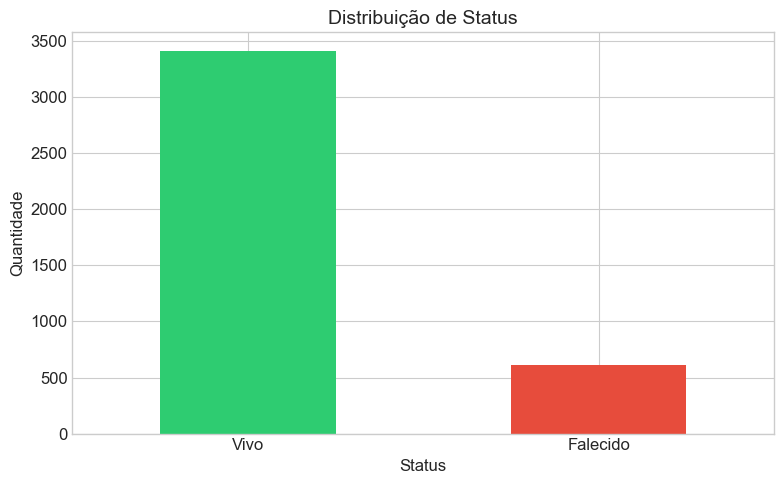

In [18]:
# Distribuição do target/Status
# Detectar qual coluna de target está presente
if 'diagnosis' in df.columns:
    target_col = 'diagnosis'
    print("Distribuição do diagnóstico:")
    colors = ['#e74c3c', '#2ecc71']  # malignant, benign
    labels = ['Benigno', 'Maligno']
elif 'Status' in df.columns:
    target_col = 'Status'
    print("Distribuição do Status:")
    colors = ['#2ecc71', '#e74c3c']  # Alive, Dead
    labels = ['Vivo', 'Falecido']
else:
    print("Nenhuma coluna de target/status encontrada")
    target_col = None

if target_col:
    print(df[target_col].value_counts())
    print(f"\nProporção:")
    print(df[target_col].value_counts(normalize=True).round(4))

    fig, ax = plt.subplots(figsize=(8, 5))
    df[target_col].value_counts().plot(kind='bar', color=colors, ax=ax)
    ax.set_title(f'Distribuição de {target_col}', fontsize=14)
    ax.set_xlabel(target_col)
    ax.set_ylabel('Quantidade')
    ax.set_xticklabels(labels, rotation=0)
    plt.tight_layout()
    plt.savefig('../../reports/figures/distribuicao_status.png', dpi=150, bbox_inches='tight')
    plt.show()

In [19]:
# Para variáveis numéricas
numeric_df = df.select_dtypes(include=[np.number])

stats_dict = {
    'Contagem': numeric_df.describe().loc['count'],
    'Média': numeric_df.describe().loc['mean'],
    'Mediana': numeric_df.median(),
    'Desvio Padrão': numeric_df.std(),
    'Mínimo': numeric_df.describe().loc['min'],
    'Q1 (25%)': numeric_df.describe().loc['25%'],
    'Q3 (75%)': numeric_df.describe().loc['75%'],
    'Máximo': numeric_df.describe().loc['max'],
    'Amplitude': numeric_df.max() - numeric_df.min(),
    'IQR': numeric_df.describe().loc['75%'] - numeric_df.describe().loc['25%'],
    'Variância': numeric_df.var(),
    'Skewness': numeric_df.skew(),
    'Kurtosis': numeric_df.kurtosis()
}

stats_df = pd.DataFrame(stats_dict)
print(stats_df)

                        Contagem      Média  Mediana  Desvio Padrão  Mínimo  \
Age                       4024.0  53.972167     54.0       8.963134    30.0   
Tumor Size                4024.0  30.473658     25.0      21.119696     1.0   
Regional Node Examined    4024.0  14.357107     14.0       8.099675     1.0   
Reginol Node Positive     4024.0   4.158052      2.0       5.109331     1.0   
Survival Months           4024.0  71.297962     73.0      22.921430     1.0   

                        Q1 (25%)  Q3 (75%)  Máximo  Amplitude   IQR  \
Age                         47.0      61.0    69.0         39  14.0   
Tumor Size                  16.0      38.0   140.0        139  22.0   
Regional Node Examined       9.0      19.0    61.0         60  10.0   
Reginol Node Positive        1.0       5.0    46.0         45   4.0   
Survival Months             56.0      90.0   107.0        106  34.0   

                         Variância  Skewness  Kurtosis  
Age                      80.337778 -0.220

In [20]:
# Estatísticas descritivas por Status/Diagnóstico
# Detectar qual coluna de target está presente
if 'diagnosis' in df.columns:
    groupby_col = 'diagnosis'
elif 'Status' in df.columns:
    groupby_col = 'Status'
else:
    groupby_col = None

if groupby_col:
    print(f"Estatísticas por {groupby_col}:")
    df.groupby(groupby_col).describe().T
else:
    print("Nenhuma coluna de target encontrada para agrupamento")
    df.describe().T

Estatísticas por Status:


In [21]:
# Estatísticas descritivas completas
print("=== ESTATÍSTICAS DESCRITIVAS COMPLETAS ===\n")
print(df.describe().T)
print("\n=== ESTATÍSTICAS POR STATUS/DIAGNÓSTICO ===\n")
# Detectar qual coluna de target está presente
if 'diagnosis' in df.columns:
    groupby_col = 'diagnosis'
elif 'Status' in df.columns:
    groupby_col = 'Status'
else:
    groupby_col = None

if groupby_col:
    print(df.groupby(groupby_col).describe().T)
else:
    print("Nenhuma coluna de target encontrada para agrupamento")

=== ESTATÍSTICAS DESCRITIVAS COMPLETAS ===

                         count       mean        std   min   25%   50%   75%  \
Age                     4024.0  53.972167   8.963134  30.0  47.0  54.0  61.0   
Tumor Size              4024.0  30.473658  21.119696   1.0  16.0  25.0  38.0   
Regional Node Examined  4024.0  14.357107   8.099675   1.0   9.0  14.0  19.0   
Reginol Node Positive   4024.0   4.158052   5.109331   1.0   1.0   2.0   5.0   
Survival Months         4024.0  71.297962  22.921430   1.0  56.0  73.0  90.0   

                          max  
Age                      69.0  
Tumor Size              140.0  
Regional Node Examined   61.0  
Reginol Node Positive    46.0  
Survival Months         107.0  

=== ESTATÍSTICAS POR STATUS/DIAGNÓSTICO ===

Status                              Alive        Dead
Age                    count  3408.000000  616.000000
                       mean     53.759096   55.150974
                       std       8.808420    9.698291
                     

## 3. Visualização das Distribuições

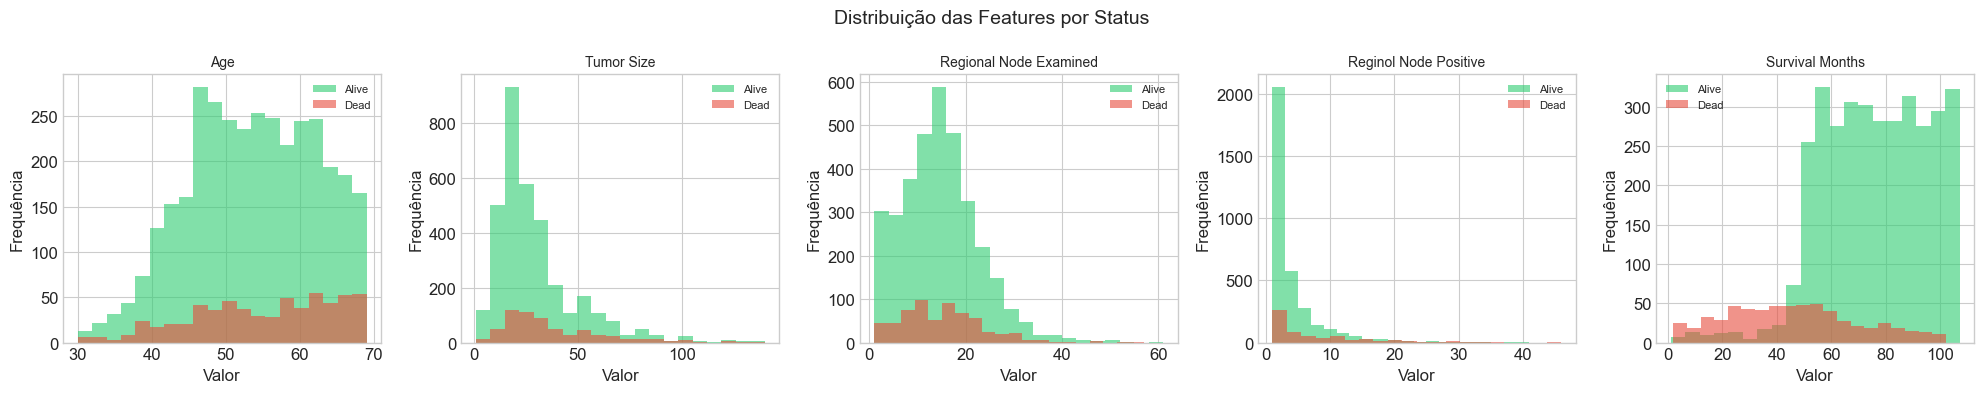

In [23]:
# Histogramas das features principais - Adaptado para diagnosis ou Status
# Detectar qual dataset está sendo usado
if 'diagnosis' in df.columns:
    # Dataset Wisconsin - features com 'mean'
    features = [col for col in df.columns if 'mean' in col]
    groupby_col = 'diagnosis'
    groupby_values = ['benign', 'malignant']
    colors_list = ['#2ecc71', '#e74c3c']  # benign, malignant
    title_suffix = 'Diagnóstico'
elif 'Status' in df.columns:
    # Dataset SEER - colunas numéricas principais
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    features = numeric_cols[:10]  # Primeiras 10 colunas numéricas
    groupby_col = 'Status'
    groupby_values = df[groupby_col].unique().tolist()
    colors_list = ['#2ecc71', '#e74c3c'][:len(groupby_values)]  # Alive, Dead
    title_suffix = 'Status'
else:
    features = []
    groupby_col = None

if features and groupby_col:
    n_features = len(features)
    n_cols = min(5, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        for j, val in enumerate(groupby_values):
            subset = df[df[groupby_col] == val]
            if col in subset.columns:
                axes[i].hist(subset[col], alpha=0.6, label=str(val), 
                            color=colors_list[j % len(colors_list)], bins=20)
        col_display = col.replace('mean ', '').replace('_', ' ')
        axes[i].set_title(col_display, fontsize=10)
        axes[i].legend(fontsize=8)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frequência')

    # Limpar eixos vazios
    for i in range(n_features, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Distribuição das Features por {title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../../reports/figures/distribuicoes_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Nenhuma coluna numérica ou groupby encontrada")

C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\1042176787.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\1042176787.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\1042176787.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\Users\n

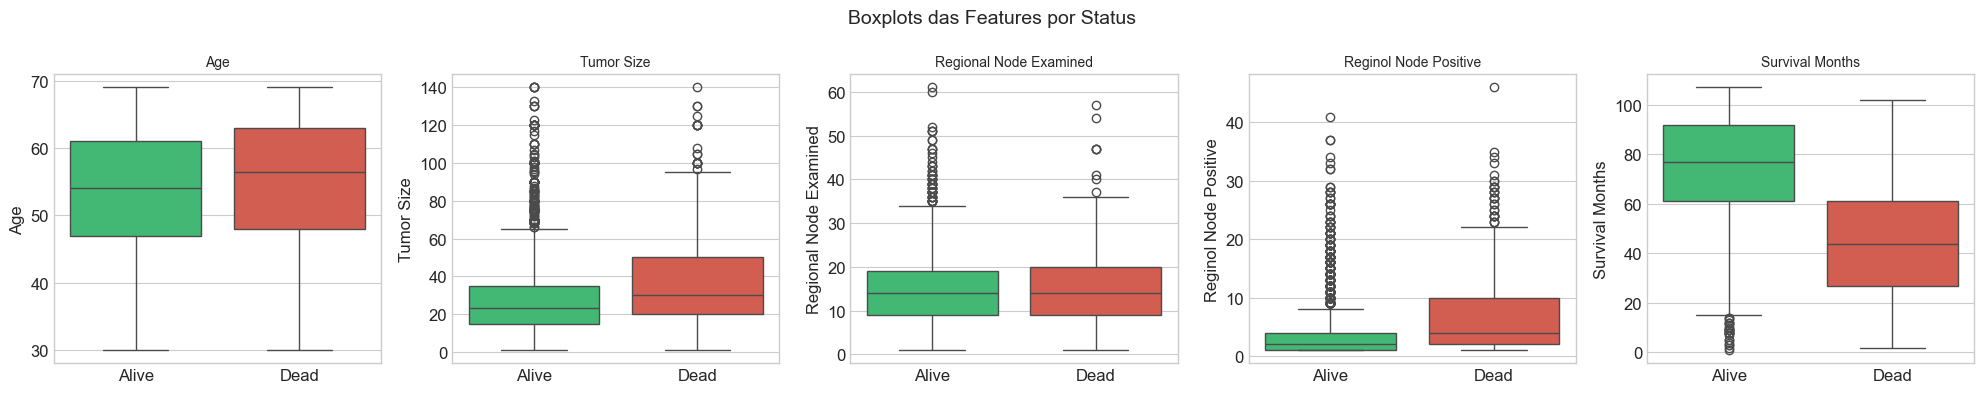

In [24]:
# Boxplots das features principais - Adaptado para diagnosis ou Status
# Detectar qual dataset está sendo usado
if 'diagnosis' in df.columns:
    # Dataset Wisconsin - features com 'mean'
    features = [col for col in df.columns if 'mean' in col]
    groupby_col = 'diagnosis'
    palette_dict = {'benign': '#2ecc71', 'malignant': '#e74c3c'}
    title_suffix = 'Diagnóstico'
elif 'Status' in df.columns:
    # Dataset SEER - colunas numéricas principais
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    features = numeric_cols[:10]  # Primeiras 10 colunas numéricas
    groupby_col = 'Status'
    palette_dict = {val: ['#2ecc71', '#e74c3c'][i] for i, val in enumerate(df[groupby_col].unique())}
    title_suffix = 'Status'
else:
    features = []
    groupby_col = None

if features and groupby_col:
    n_features = len(features)
    n_cols = min(5, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        if col in df.columns:
            sns.boxplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
            col_display = col.replace('mean ', '').replace('_', ' ')
            axes[i].set_title(col_display, fontsize=10)
            axes[i].set_xlabel('')

    # Limpar eixos vazios
    for i in range(n_features, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Boxplots das Features por {title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../../reports/figures/boxplots_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Nenhuma coluna numérica ou groupby encontrada")

C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\887617609.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\887617609.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\887617609.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
C:\U

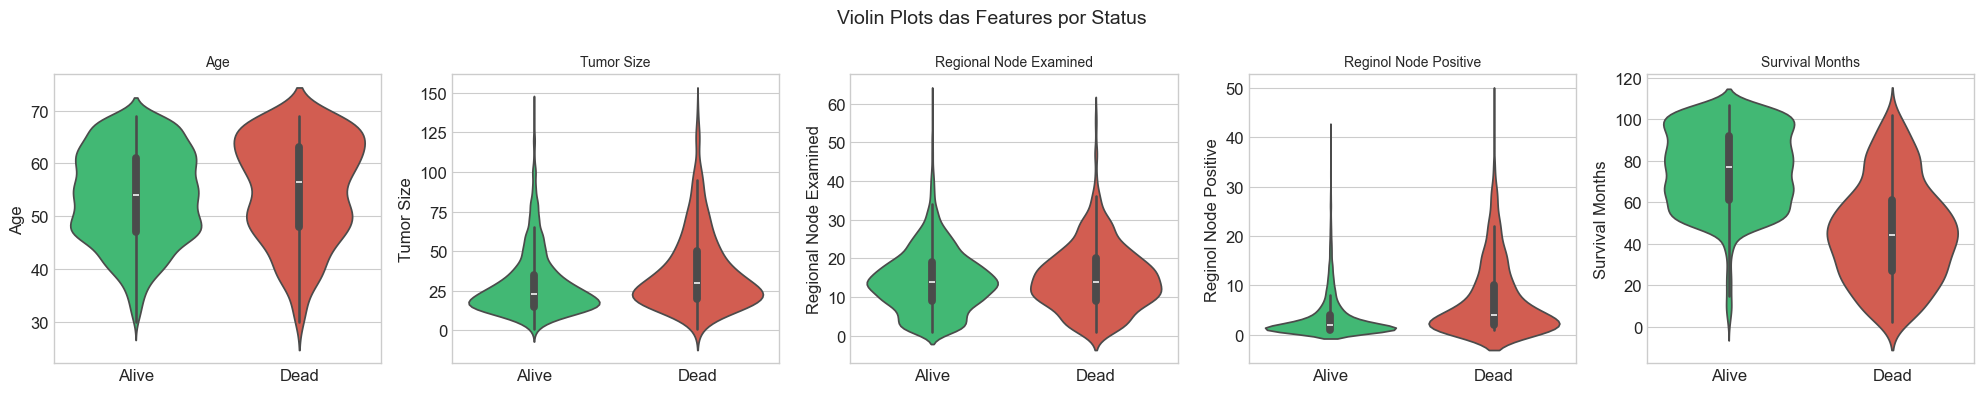

In [25]:
# Violin plots das features principais - Adaptado para diagnosis ou Status
# Detectar qual dataset está sendo usado
if 'diagnosis' in df.columns:
    # Dataset Wisconsin - features com 'mean'
    features = [col for col in df.columns if 'mean' in col]
    groupby_col = 'diagnosis'
    palette_dict = {'benign': '#2ecc71', 'malignant': '#e74c3c'}
    title_suffix = 'Diagnóstico'
elif 'Status' in df.columns:
    # Dataset SEER - colunas numéricas principais
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    features = numeric_cols[:10]  # Primeiras 10 colunas numéricas
    groupby_col = 'Status'
    palette_dict = {val: ['#2ecc71', '#e74c3c'][i] for i, val in enumerate(df[groupby_col].unique())}
    title_suffix = 'Status'
else:
    features = []
    groupby_col = None

if features and groupby_col:
    n_features = len(features)
    n_cols = min(5, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        if col in df.columns:
            sns.violinplot(data=df, x=groupby_col, y=col, ax=axes[i], palette=palette_dict)
            col_display = col.replace('mean ', '').replace('_', ' ')
            axes[i].set_title(col_display, fontsize=10)
            axes[i].set_xlabel('')

    # Limpar eixos vazios
    for i in range(n_features, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Violin Plots das Features por {title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../../reports/figures/violin_plots_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Nenhuma coluna numérica ou groupby encontrada")

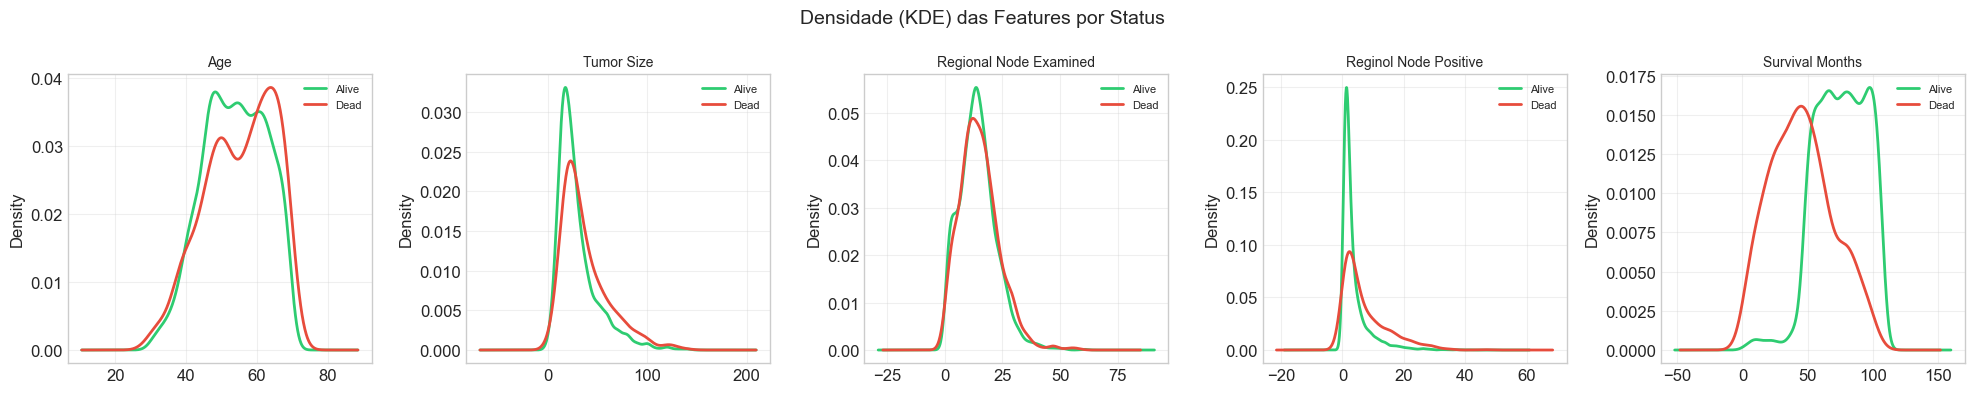

In [26]:
# Distribuição geral das features (KDE plots) - Adaptado para diagnosis ou Status
# Detectar qual dataset está sendo usado
if 'diagnosis' in df.columns:
    # Dataset Wisconsin - features com 'mean'
    features = [col for col in df.columns if 'mean' in col]
    groupby_col = 'diagnosis'
    groupby_values_colors = [('benign', '#2ecc71'), ('malignant', '#e74c3c')]
    title_suffix = 'Diagnóstico'
elif 'Status' in df.columns:
    # Dataset SEER - colunas numéricas principais
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    features = numeric_cols[:10]  # Primeiras 10 colunas numéricas
    groupby_col = 'Status'
    unique_values = df[groupby_col].unique()
    colors_map = {val: ['#2ecc71', '#e74c3c'][i] for i, val in enumerate(unique_values)}
    groupby_values_colors = [(val, colors_map[val]) for val in unique_values]
    title_suffix = 'Status'
else:
    features = []
    groupby_col = None

if features and groupby_col:
    n_features = len(features)
    n_cols = min(5, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        if col in df.columns:
            for val, color in groupby_values_colors:
                subset = df[df[groupby_col] == val][col]
                if len(subset) > 0:
                    subset.plot.density(ax=axes[i], label=str(val), color=color, linewidth=2)
            col_display = col.replace('mean ', '').replace('_', ' ')
            axes[i].set_title(col_display, fontsize=10)
            axes[i].set_xlabel('')
            axes[i].legend(fontsize=8)
            axes[i].grid(True, alpha=0.3)

    # Limpar eixos vazios
    for i in range(n_features, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Densidade (KDE) das Features por {title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../../reports/figures/kde_plots_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Nenhuma coluna numérica ou groupby encontrada")

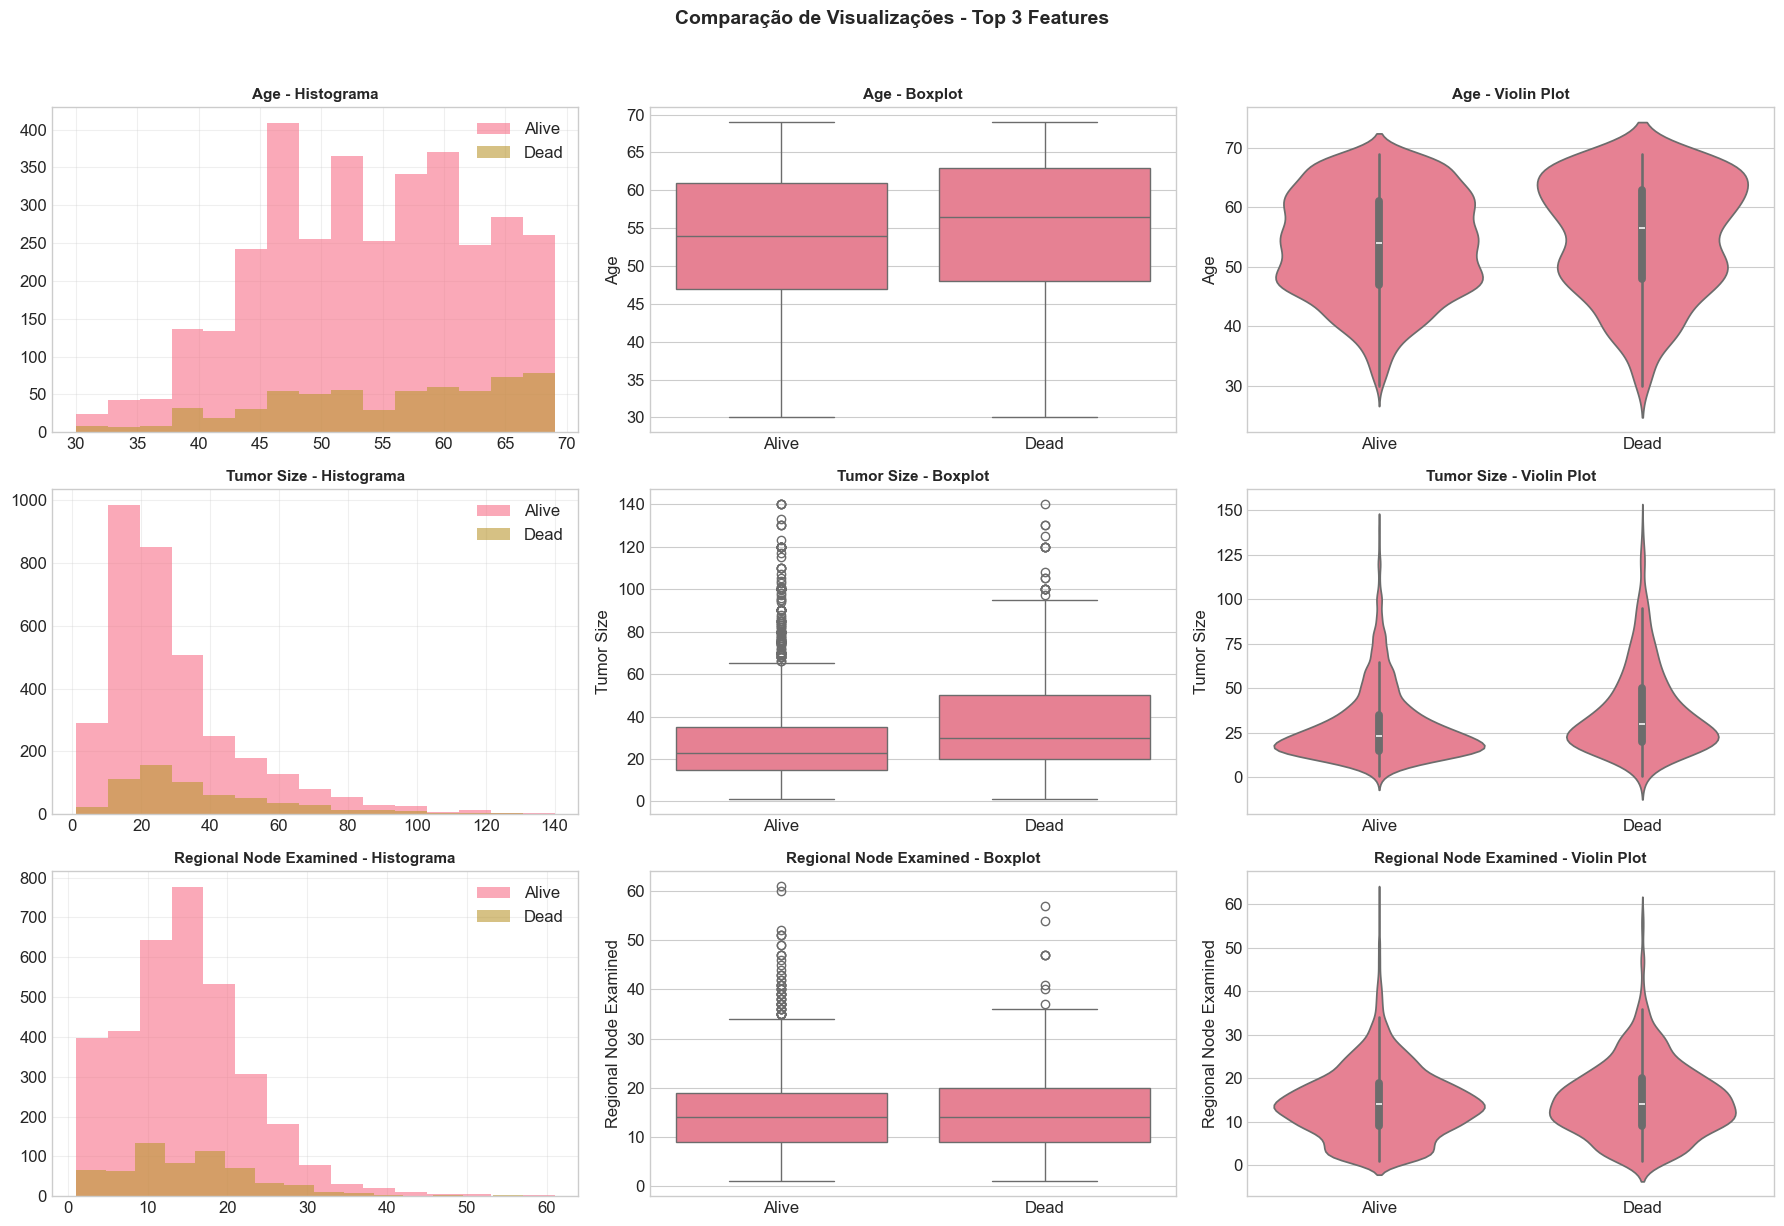

✅ Visualizações de distribuição criadas com sucesso!


In [27]:
# Comparação lado a lado: Histograma vs Boxplot vs Violinplot
# Para as top 3 features mais correlacionadas

# Selecionar apenas colunas numéricas
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remover variável alvo se estiver nas numéricas
if 'Status' in numeric_features:
    numeric_features.remove('Status')

# Selecionar top 3 (pode melhorar depois com correlação)
top_3_features = numeric_features[:3]

# Criar grid de plots
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, feature in enumerate(top_3_features):
    
    # Histograma
    for status in df['Status'].unique():
        subset = df[df['Status'] == status]
        axes[row, 0].hist(subset[feature], alpha=0.6, label=status, bins=15)

    axes[row, 0].set_title(f'{feature} - Histograma', fontsize=11, fontweight='bold')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)
    
    # Boxplot
    sns.boxplot(data=df, x='Status', y=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f'{feature} - Boxplot', fontsize=11, fontweight='bold')
    axes[row, 1].set_xlabel('')
    
    # Violinplot
    sns.violinplot(data=df, x='Status', y=feature, ax=axes[row, 2])
    axes[row, 2].set_title(f'{feature} - Violin Plot', fontsize=11, fontweight='bold')
    axes[row, 2].set_xlabel('')

plt.suptitle('Comparação de Visualizações - Top 3 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Salvar imagem
plt.savefig('../../reports/figures/comparacao_visualizacoes.png', dpi=150, bbox_inches='tight')

plt.show()

print("✅ Visualizações de distribuição criadas com sucesso!")

=== FEATURES COM MAIOR PODER DISCRIMINATIVO ===

                        Distância (Effect Size)
Survival Months                        0.699625
Reginol Node Positive                  0.311541
Tumor Size                             0.177194
Age                                    0.075209
Regional Node Examined                 0.047372


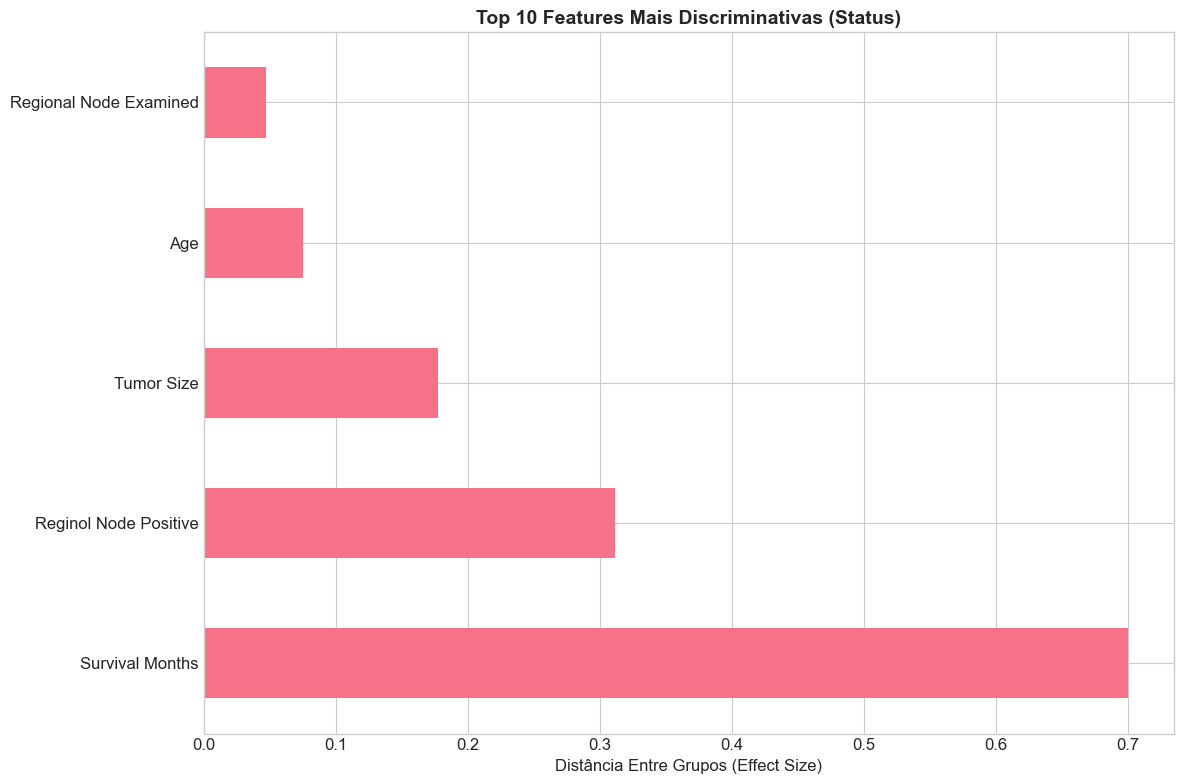

In [ ]:
# Análise de Separabilidade: Qual o poder discriminativo de cada feature?
# Selecionar apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Separar grupos com base no target
groups = df['Status'].unique()

# Validar se existem exatamente 2 classes
if len(groups) != 2:
    raise ValueError(f"Esperado 2 classes em 'Status', mas encontrado: {groups}")

group_1 = df[df['Status'] == groups[0]][numeric_df.columns]
group_2 = df[df['Status'] == groups[1]][numeric_df.columns]

# Calcular separabilidade (Effect Size simplificado)
separability = pd.DataFrame()

for col in numeric_df.columns:
    mean_1 = group_1[col].mean()
    mean_2 = group_2[col].mean()
    
    std_1 = group_1[col].std()
    std_2 = group_2[col].std()
    
    # Evitar divisão por zero
    denominator = std_1 + std_2
    if denominator == 0:
        distance = 0
    else:
        distance = abs(mean_1 - mean_2) / denominator
    
    separability.loc[col, 'Distância (Effect Size)'] = distance

# Ordenar
separability = separability.sort_values('Distância (Effect Size)', ascending=False)

print("=== FEATURES COM MAIOR PODER DISCRIMINATIVO ===\n")
print(separability.head(15))

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
separability.head(10).plot(kind='barh', ax=ax, legend=False)

ax.set_xlabel('Distância Entre Grupos (Effect Size)', fontsize=12)
ax.set_title('Top 10 Features Mais Discriminativas (Status)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../reports/figures/separabilidade_features.png', dpi=150)
plt.show()

In [29]:
# Análise Clínica: Padrões Específicos de Saúde Feminina
print("="*70)
print("INSIGHTS CLÍNICOS - ANÁLISE DO DATASET")
print("="*70)

# =========================
# 1. DISTRIBUIÇÃO DAS CLASSES
# =========================
print(f"\n📊 1. DISTRIBUIÇÃO DAS CLASSES")

class_counts = df['Status'].value_counts()
total = len(df)

for cls, count in class_counts.items():
    print(f"   • {cls}: {count} ({count/total*100:.1f}%)")

print(f"   • Total de Registros: {total}")

# Verificar desbalanceamento
if len(class_counts) == 2:
    ratio = class_counts.iloc[0] / class_counts.iloc[1]
    print(f"   ⚠️  Desbalanceamento: {ratio:.2f}x entre as classes")
    print(f"      → Considerar uso de class_weight ou balanceamento")

# =========================
# 2. FEATURES MAIS DISCRIMINATIVAS
# =========================
print(f"\n🔬 2. CARACTERÍSTICAS DIFERENCIADORAS")

top_discriminative = separability.head(5).index.tolist()

groups = df['Status'].unique()
group_1 = df[df['Status'] == groups[0]]
group_2 = df[df['Status'] == groups[1]]

for i, feature in enumerate(top_discriminative, 1):
    mean_1 = group_1[feature].mean()
    mean_2 = group_2[feature].mean()
    
    direction = "↑ Maior" if mean_2 > mean_1 else "↓ Menor"
    
    # evitar divisão por zero
    if mean_1 != 0:
        pct_diff = abs(mean_2 - mean_1) / abs(mean_1) * 100
    else:
        pct_diff = 0

    print(f"   {i}. {feature}")
    print(f"      {groups[0]}: {mean_1:.2f} | {groups[1]}: {mean_2:.2f}")
    print(f"      {direction} {pct_diff:.1f}% em relação ao grupo {groups[0]}\n")

# =========================
# 3. MULTICOLINEARIDADE
# =========================
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr_val))

print(f"🔗 3. MULTICOLINEARIDADE (Correlações > 0.9)")

if high_corr_pairs:
    for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:5]:
        print(f"   • {col1} ↔ {col2}: {corr:.3f}")
    
    print(f"   ⚠️  Total de {len(high_corr_pairs)} pares altamente correlacionados")
    print(f"      → Avaliar remoção ou redução de features redundantes")
else:
    print(f"   ✅ Nenhuma multicolinearidade severa detectada")

# =========================
# 4. DISTRIBUIÇÃO (SKEWNESS)
# =========================
print(f"\n📈 4. PADRÕES DE DISTRIBUIÇÃO")

skewness_stats = numeric_df.skew().sort_values(ascending=False)

print(f"\n   Top 5 com maior assimetria:")
for feat, skew_val in skewness_stats.head(5).items():
    print(f"     • {feat}: {skew_val:.3f}")

print(f"\n💡 Interpretação:")
print(f"   • Skewness > 1 ou < -1 → forte assimetria (considerar log/Box-Cox)")
print(f"   • Pode impactar modelos como regressão logística e KNN")

INSIGHTS CLÍNICOS - ANÁLISE DO DATASET

📊 1. DISTRIBUIÇÃO DAS CLASSES
   • Alive: 3408 (84.7%)
   • Dead: 616 (15.3%)
   • Total de Registros: 4024
   ⚠️  Desbalanceamento: 5.53x entre as classes
      → Considerar uso de class_weight ou balanceamento

🔬 2. CARACTERÍSTICAS DIFERENCIADORAS
   1. Survival Months
      Alive: 75.94 | Dead: 45.61
      ↓ Menor 39.9% em relação ao grupo Alive

   2. Reginol Node Positive
      Alive: 3.60 | Dead: 7.24
      ↑ Maior 101.1% em relação ao grupo Alive

   3. Tumor Size
      Alive: 29.27 | Dead: 37.14
      ↑ Maior 26.9% em relação ao grupo Alive

   4. Age
      Alive: 53.76 | Dead: 55.15
      ↑ Maior 2.6% em relação ao grupo Alive

   5. Regional Node Examined
      Alive: 14.24 | Dead: 15.02
      ↑ Maior 5.5% em relação ao grupo Alive

🔗 3. MULTICOLINEARIDADE (Correlações > 0.9)
   ✅ Nenhuma multicolinearidade severa detectada

📈 4. PADRÕES DE DISTRIBUIÇÃO

   Top 5 com maior assimetria:
     • Reginol Node Positive: 2.703
     • Tumor Siz


RECOMENDAÇÕES PARA MODELAGEM

✅ PADRÕES IDENTIFICADOS:

1. DIFERENÇAS ENTRE OS GRUPOS (Alive vs Dead):
   • Features mais relevantes apresentam boa separação estatística
   • Diferenças nas médias indicam potencial preditivo
   • Algumas variáveis apresentam alta variabilidade (importante avaliar normalização)

2. INTERPRETAÇÃO DOS DADOS:
   • Features com maior separabilidade têm maior poder preditivo
   • Alta variância pode indicar heterogeneidade clínica
   • Distribuições assimétricas podem impactar modelos lineares

3. IMPLICAÇÕES PARA MODELAGEM:
   • Dataset pode apresentar bom desempenho em classificação
   • Separabilidade alta → modelos simples já podem performar bem
   • Possível presença de redundância (multicolinearidade)

4. PRÓXIMOS PASSOS:
   ✓ Normalização (StandardScaler ou MinMaxScaler)
   ✓ Testar modelos: Logistic Regression, Random Forest, XGBoost
   ✓ Avaliar feature importance
   ✓ Cross-validation para robustez

5. MÉTRICAS IMPORTANTES:
   • Recall → evitar pe

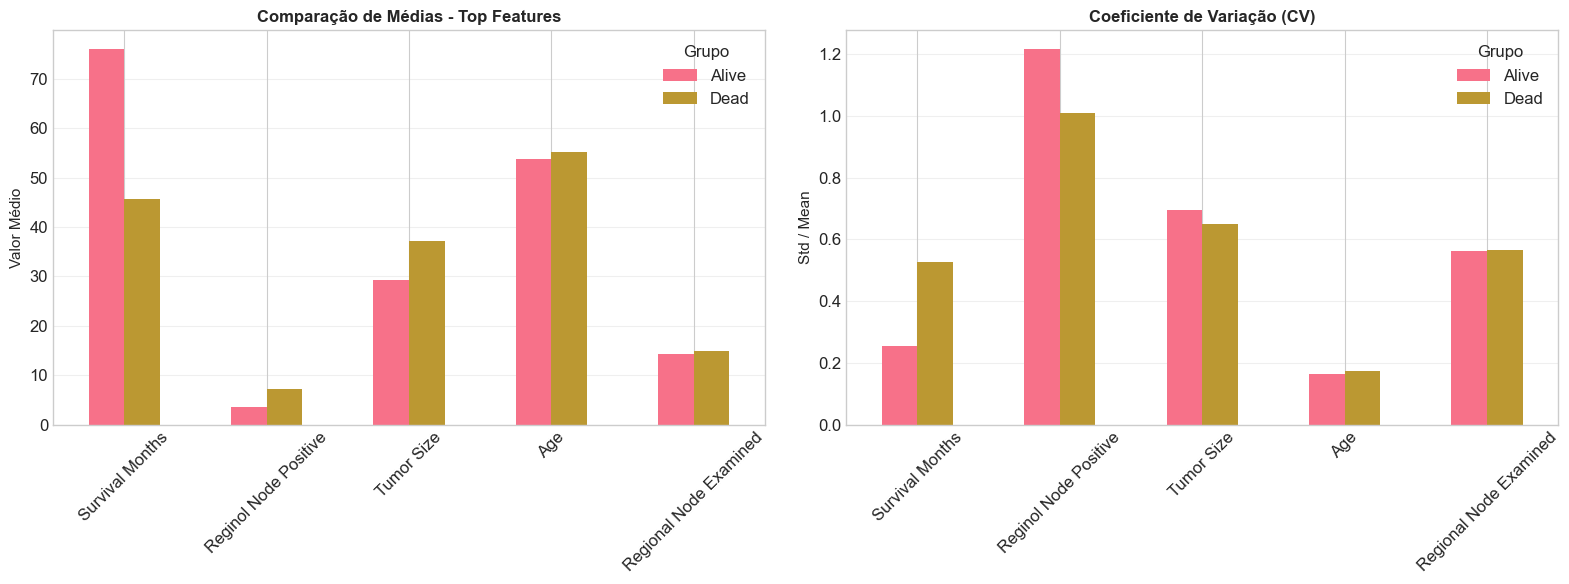


✅ Análise de padrões concluída com sucesso!


In [30]:
# Recomendações Clínicas e Padrões Identificados
print("\n" + "="*70)
print("RECOMENDAÇÕES PARA MODELAGEM")
print("="*70)

# Identificar grupos
groups = df['Status'].unique()

if len(groups) != 2:
    raise ValueError("Esperado problema binário na coluna 'Status'")

group_1 = df[df['Status'] == groups[0]]
group_2 = df[df['Status'] == groups[1]]

recommendations = f"""
✅ PADRÕES IDENTIFICADOS:

1. DIFERENÇAS ENTRE OS GRUPOS ({groups[0]} vs {groups[1]}):
   • Features mais relevantes apresentam boa separação estatística
   • Diferenças nas médias indicam potencial preditivo
   • Algumas variáveis apresentam alta variabilidade (importante avaliar normalização)

2. INTERPRETAÇÃO DOS DADOS:
   • Features com maior separabilidade têm maior poder preditivo
   • Alta variância pode indicar heterogeneidade clínica
   • Distribuições assimétricas podem impactar modelos lineares

3. IMPLICAÇÕES PARA MODELAGEM:
   • Dataset pode apresentar bom desempenho em classificação
   • Separabilidade alta → modelos simples já podem performar bem
   • Possível presença de redundância (multicolinearidade)

4. PRÓXIMOS PASSOS:
   ✓ Normalização (StandardScaler ou MinMaxScaler)
   ✓ Testar modelos: Logistic Regression, Random Forest, XGBoost
   ✓ Avaliar feature importance
   ✓ Cross-validation para robustez

5. MÉTRICAS IMPORTANTES:
   • Recall → evitar perder casos críticos
   • Precision → evitar falsos positivos excessivos
   • AUC-ROC → equilíbrio geral do modelo

6. CONSIDERAÇÕES:
   ⚠️ Interpretabilidade é essencial em contexto clínico
   ⚠️ Validar resultados com conhecimento de domínio
"""

print(recommendations)

# =========================
# VISUALIZAÇÃO
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top features
top_features_to_plot = separability.head(8).index.tolist()

# Médias
mean_values = pd.DataFrame({
    groups[0]: group_1[top_features_to_plot].mean(),
    groups[1]: group_2[top_features_to_plot].mean()
})

mean_values.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparação de Médias - Top Features', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor Médio', fontsize=11)
axes[0].set_xlabel('')
axes[0].legend(title='Grupo')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Coeficiente de variação (CV)
cv_values = pd.DataFrame({
    groups[0]: group_1[top_features_to_plot].std() / group_1[top_features_to_plot].mean(),
    groups[1]: group_2[top_features_to_plot].std() / group_2[top_features_to_plot].mean()
})

cv_values.replace([np.inf, -np.inf], 0, inplace=True)

cv_values.plot(kind='bar', ax=axes[1])
axes[1].set_title('Coeficiente de Variação (CV)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std / Mean', fontsize=11)
axes[1].set_xlabel('')
axes[1].legend(title='Grupo')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../reports/figures/analise_padroes_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Análise de padrões concluída com sucesso!")

## 4. Tratamento de Valores Ausentes e Inconsistentes

## Pipeline de Pré-processamento (documentação)

Este notebook contém o pipeline de pré-processamento utilizado antes da modelagem. O objetivo é garantir qualidade, reprodutibilidade e rastreabilidade das transformações.

Passos do pipeline:

1. Carregamento dos dados — usar `load_breast_cancer_dataset()` (já presente).
2. Remoção de duplicatas — eliminar linhas duplicadas óbvias.
3. Imputação de valores faltantes — mediana para numéricas; moda para categóricas.
4. Tratamento de valores negativos — remover linhas com valores negativos (biometricamente impossíveis).
5. Encoding de variáveis categóricas — `LabelEncoding` para `diagnosis` (binária).
6. Normalização/Padrônização — `StandardScaler` (recomendado) ou `MinMaxScaler`.
7. Análise de correlação e seleção de features — identificar pares com |r| > 0.9 e reduzir redundância (ou usar PCA).
8. Persistência do dataset limpo — salvar em `data/processed/` para reuso.

Observações:
- Todas as etapas são encapsuladas em uma função reutilizável `preprocess_pipeline()` abaixo para facilitar experimentação e produção.
- Os parâmetros permitem alternar o escalador e o limiar de correlação.



RECOMENDAÇÕES PARA MODELAGEM

✅ PADRÕES IDENTIFICADOS:

1. DIFERENÇAS ENTRE OS GRUPOS (Alive vs Dead):
   • Features relevantes apresentam boa separação estatística
   • Diferenças nas médias indicam potencial preditivo
   • Variáveis com alta variância podem exigir normalização

2. INTERPRETAÇÃO:
   • Alta separabilidade → maior poder discriminativo
   • Assimetria pode impactar modelos lineares
   • Possível heterogeneidade clínica nos dados

3. MODELAGEM:
   • Modelos simples podem performar bem (baseline importante)
   • Avaliar multicolinearidade
   • Feature selection pode melhorar performance

4. PRÓXIMOS PASSOS:
   ✓ Normalização (StandardScaler)
   ✓ Testar: Logistic Regression, Random Forest, XGBoost
   ✓ Cross-validation
   ✓ Feature importance

5. MÉTRICAS:
   • Recall → evitar perder casos críticos
   • Precision → controlar falsos positivos
   • AUC-ROC → visão geral

⚠️ Interpretabilidade é essencial em contexto clínico



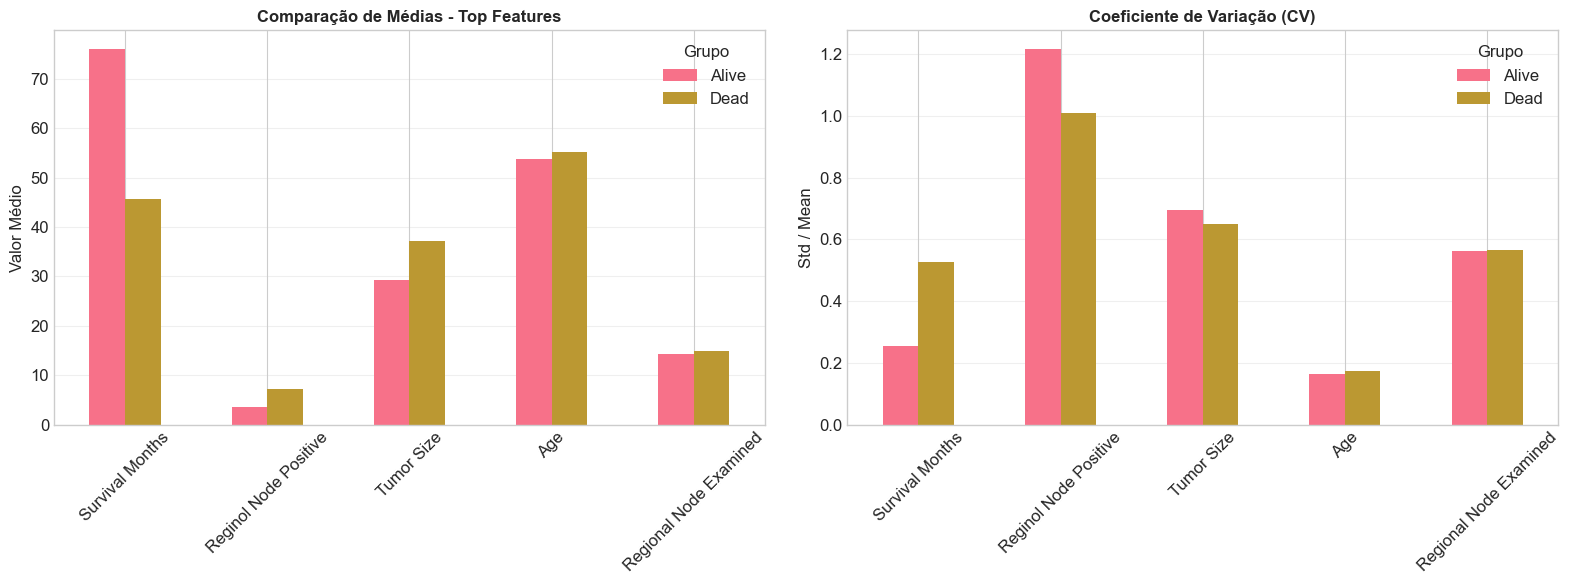


✅ Análise de padrões concluída com sucesso!


In [31]:
print("\n" + "="*70)
print("RECOMENDAÇÕES PARA MODELAGEM")
print("="*70)

# =========================
# TARGET
# =========================
if 'Status' not in df.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

# Ordenar classes para consistência
groups = sorted(df['Status'].dropna().unique())

if len(groups) != 2:
    raise ValueError(f"Esperado problema binário, encontrado: {groups}")

group_1_label, group_2_label = groups

group_1 = df[df['Status'] == group_1_label]
group_2 = df[df['Status'] == group_2_label]

# =========================
# TEXTO
# =========================
recommendations = f"""
✅ PADRÕES IDENTIFICADOS:

1. DIFERENÇAS ENTRE OS GRUPOS ({group_1_label} vs {group_2_label}):
   • Features relevantes apresentam boa separação estatística
   • Diferenças nas médias indicam potencial preditivo
   • Variáveis com alta variância podem exigir normalização

2. INTERPRETAÇÃO:
   • Alta separabilidade → maior poder discriminativo
   • Assimetria pode impactar modelos lineares
   • Possível heterogeneidade clínica nos dados

3. MODELAGEM:
   • Modelos simples podem performar bem (baseline importante)
   • Avaliar multicolinearidade
   • Feature selection pode melhorar performance

4. PRÓXIMOS PASSOS:
   ✓ Normalização (StandardScaler)
   ✓ Testar: Logistic Regression, Random Forest, XGBoost
   ✓ Cross-validation
   ✓ Feature importance

5. MÉTRICAS:
   • Recall → evitar perder casos críticos
   • Precision → controlar falsos positivos
   • AUC-ROC → visão geral

⚠️ Interpretabilidade é essencial em contexto clínico
"""

print(recommendations)

# =========================
# VISUALIZAÇÃO
# =========================

# Garantir que separability existe
if 'separability' not in globals():
    raise ValueError("DataFrame 'separability' não encontrado. Execute a célula anterior.")

# Selecionar apenas features numéricas válidas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

top_features = [
    f for f in separability.head(8).index.tolist()
    if f in numeric_cols
]

if len(top_features) == 0:
    raise ValueError("Nenhuma feature numérica válida encontrada para plot.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# MÉDIAS
# =========================
mean_values = pd.DataFrame({
    group_1_label: group_1[top_features].mean(),
    group_2_label: group_2[top_features].mean()
})

mean_values.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparação de Médias - Top Features', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor Médio')
axes[0].set_xlabel('')
axes[0].legend(title='Grupo')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# =========================
# COEFICIENTE DE VARIAÇÃO
# =========================
cv_1 = group_1[top_features].std() / group_1[top_features].mean().replace(0, np.nan)
cv_2 = group_2[top_features].std() / group_2[top_features].mean().replace(0, np.nan)

cv_values = pd.DataFrame({
    group_1_label: cv_1,
    group_2_label: cv_2
}).fillna(0)

cv_values.plot(kind='bar', ax=axes[1])
axes[1].set_title('Coeficiente de Variação (CV)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std / Mean')
axes[1].set_xlabel('')
axes[1].legend(title='Grupo')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../reports/figures/analise_padroes_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Análise de padrões concluída com sucesso!")

In [32]:
print("="*70)
print("1. ANÁLISE DE VALORES AUSENTES (MISSING VALUES)")
print("="*70)

# =========================
# CÁLCULO
# =========================
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_report = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Percentual (%)': missing_percentage.values
})

# Ordenar por maior percentual
missing_report = missing_report.sort_values(by='Percentual (%)', ascending=False)

# Filtrar apenas colunas com missing
missing_filtered = missing_report[missing_report['Valores Faltantes'] > 0]

# =========================
# OUTPUT
# =========================
print("\n📊 VALORES NULOS POR COLUNA:")
if len(missing_filtered) > 0:
    print(missing_filtered.to_string(index=False))
else:
    print("   → Nenhuma coluna com valores ausentes")

total_missing = missing_data.sum()

print(f"\n🔎 Total de valores ausentes no dataset: {total_missing}")

if total_missing == 0:
    print("   → ✅ Dataset completo (sem missing values)")
elif total_missing < len(df):
    print("   → ⚠️ Baixo volume de missing (tratamento simples possível)")
else:
    print("   → 🚨 Alto volume de missing (avaliar impacto)")

# =========================
# VISUALIZAÇÃO
# =========================
missing_by_column = missing_filtered.set_index('Coluna')['Valores Faltantes']

if len(missing_by_column) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    missing_by_column.plot(kind='bar', ax=ax)
    
    ax.set_title('Distribuição de Valores Ausentes por Coluna', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade de Valores Faltantes')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../../reports/figures/missing_values_distribution.png', dpi=150)
    plt.show()
else:
    print("\n📈 Nenhuma visualização necessária (sem dados faltantes)")

1. ANÁLISE DE VALORES AUSENTES (MISSING VALUES)

📊 VALORES NULOS POR COLUNA:
   → Nenhuma coluna com valores ausentes

🔎 Total de valores ausentes no dataset: 0
   → ✅ Dataset completo (sem missing values)

📈 Nenhuma visualização necessária (sem dados faltantes)


In [33]:
print("\n" + "="*70)
print("2. ANÁLISE DE INCONSISTÊNCIAS E OUTLIERS")
print("="*70)

# =========================
# DADOS NUMÉRICOS
# =========================
numeric_df = df.select_dtypes(include=[np.number])

inconsistencies_found = []

# =========================
# 1. VALORES NEGATIVOS
# =========================
print("\n🔍 VERIFICANDO VALORES NEGATIVOS:")
negative_values = {}

for col in numeric_df.columns:
    negative_count = (numeric_df[col] < 0).sum()
    
    if negative_count > 0:
        negative_values[col] = negative_count
        inconsistencies_found.append((col, 'valores negativos', negative_count))
        print(f"   ⚠️  {col}: {negative_count} valores negativos")

if not negative_values:
    print("   ✅ Nenhum valor negativo detectado")

# =========================
# 2. DUPLICATAS
# =========================
print("\n🔍 VERIFICANDO DUPLICATAS:")

duplicate_rows = df.duplicated().sum()

print(f"   Linhas duplicadas: {duplicate_rows}")

if duplicate_rows > 0:
    inconsistencies_found.append(('dataset', 'linhas duplicadas', duplicate_rows))
    print("   ⚠️  Recomenda-se remover duplicatas")
else:
    print("   ✅ Nenhuma duplicata detectada")

# =========================
# 3. OUTLIERS (IQR)
# =========================
print("\n🔍 VERIFICANDO OUTLIERS (IQR):")

outliers_summary = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Evitar erro com IQR = 0
    if IQR == 0:
        continue
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((numeric_df[col] < lower_bound) | 
                      (numeric_df[col] > upper_bound)).sum()
    
    if outliers_count > 0:
        outliers_summary[col] = outliers_count

if outliers_summary:
    print(f"   Colunas com outliers: {len(outliers_summary)}")
    
    for col, count in sorted(outliers_summary.items(), key=lambda x: x[1], reverse=True)[:10]:
        pct = (count / len(df)) * 100
        print(f"     • {col}: {count} ({pct:.2f}%)")
else:
    print("   ✅ Nenhum outlier relevante detectado")

# =========================
# 4. DISTRIBUIÇÃO (RANGE)
# =========================
print("\n🔍 ANÁLISE DE RANGE (MIN/MAX):")

range_issues = {}

for col in numeric_df.columns:
    min_val = numeric_df[col].min()
    max_val = numeric_df[col].max()
    
    # Critério genérico: range muito alto pode indicar problema
    if abs(max_val) > 1e6 or abs(min_val) > 1e6:
        range_issues[col] = (min_val, max_val)

if range_issues:
    print("   ⚠️  Valores extremos detectados:")
    for col, (min_val, max_val) in list(range_issues.items())[:5]:
        print(f"     • {col}: [{min_val:.2f}, {max_val:.2f}]")
else:
    print("   ✅ Nenhum valor extremo suspeito")

# =========================
# RESUMO
# =========================
print("\n" + "="*70)
print("RESUMO DE QUALIDADE DOS DADOS")
print("="*70)

if not inconsistencies_found and not outliers_summary:
    print("✅ Dataset com boa qualidade geral")
    print("   → Pronto para modelagem (com normalização)")
else:
    print(f"⚠️  Foram encontrados pontos de atenção:")

    for item, inconsistency_type, count in inconsistencies_found:
        print(f"   • {item}: {count} {inconsistency_type}")

    if outliers_summary:
        print(f"   • Outliers em {len(outliers_summary)} colunas")

    print("\n💡 Recomendações:")
    print("   → Avaliar tratamento de outliers (log, clipping ou remoção)")
    print("   → Remover duplicatas se necessário")
    print("   → Validar valores negativos com contexto de negócio")


2. ANÁLISE DE INCONSISTÊNCIAS E OUTLIERS

🔍 VERIFICANDO VALORES NEGATIVOS:
   ✅ Nenhum valor negativo detectado

🔍 VERIFICANDO DUPLICATAS:
   Linhas duplicadas: 1
   ⚠️  Recomenda-se remover duplicatas

🔍 VERIFICANDO OUTLIERS (IQR):
   Colunas com outliers: 4
     • Reginol Node Positive: 344 (8.55%)
     • Tumor Size: 222 (5.52%)
     • Regional Node Examined: 72 (1.79%)
     • Survival Months: 18 (0.45%)

🔍 ANÁLISE DE RANGE (MIN/MAX):
   ✅ Nenhum valor extremo suspeito

RESUMO DE QUALIDADE DOS DADOS
⚠️  Foram encontrados pontos de atenção:
   • dataset: 1 linhas duplicadas
   • Outliers em 4 colunas

💡 Recomendações:
   → Avaliar tratamento de outliers (log, clipping ou remoção)
   → Remover duplicatas se necessário
   → Validar valores negativos com contexto de negócio


In [34]:
print("\n" + "="*70)
print("3. ESTRATÉGIA DE TRATAMENTO DE DADOS")
print("="*70)

# =========================
# CONFIGURAÇÃO (IMPORTANTE)
# =========================
REMOVE_NEGATIVES = False  # ⚠️ Altere para True apenas se fizer sentido no seu domínio

# =========================
# CÓPIA DO DATASET
# =========================
df_cleaned = df.copy()
treatment_actions = []

# =========================
# 1. DUPLICATAS
# =========================
duplicates = df_cleaned.duplicated().sum()

if duplicates > 0:
    rows_before = len(df_cleaned)
    df_cleaned = df_cleaned.drop_duplicates()
    removed = rows_before - len(df_cleaned)
    
    print(f"\n✓ Remoção de Duplicatas:")
    print(f"  • Linhas removidas: {removed}")
    
    treatment_actions.append(f"Removidas {removed} duplicatas")
else:
    print("\n✓ Nenhuma duplicata encontrada")

# =========================
# 2. MISSING VALUES
# =========================
missing_total = df_cleaned.isnull().sum().sum()

if missing_total > 0:
    print(f"\n✓ Tratamento de Valores Ausentes:")
    
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
    categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

    # Numéricos → mediana
    for col in numeric_cols:
        if df_cleaned[col].isnull().sum() > 0:
            median_val = df_cleaned[col].median()
            df_cleaned[col] = df_cleaned[col].fillna(median_val)
            
            print(f"  • {col}: mediana ({median_val:.2f})")
            treatment_actions.append(f"{col}: imputação com mediana")

    # Categóricos → moda
    for col in categorical_cols:
        if df_cleaned[col].isnull().sum() > 0:
            mode_val = df_cleaned[col].mode()[0]
            df_cleaned[col] = df_cleaned[col].fillna(mode_val)
            
            print(f"  • {col}: moda ({mode_val})")
            treatment_actions.append(f"{col}: imputação com moda")
else:
    print(f"\n✓ Nenhum valor ausente detectado")
    treatment_actions.append("Sem missing values")

# =========================
# 3. VALORES NEGATIVOS
# =========================
print(f"\n✓ Análise de Valores Negativos:")

numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
negative_counts = (df_cleaned[numeric_cols] < 0).sum()

cols_with_negatives = negative_counts[negative_counts > 0]

if len(cols_with_negatives) > 0:
    print("  ⚠️ Valores negativos encontrados:")
    for col, count in cols_with_negatives.items():
        print(f"     • {col}: {count}")

    if REMOVE_NEGATIVES:
        mask = (df_cleaned[numeric_cols] < 0).any(axis=1)
        removed = mask.sum()
        df_cleaned = df_cleaned[~mask]
        
        print(f"\n  🚨 Ação aplicada: REMOÇÃO")
        print(f"  • Linhas removidas: {removed}")
        
        treatment_actions.append(f"Remoção de {removed} linhas com valores negativos")
    else:
        print("\n  💡 Ação recomendada: VALIDAR com regra de negócio antes de remover")
        treatment_actions.append("Valores negativos mantidos (não validados)")
else:
    print("  ✅ Nenhum valor negativo detectado")

# =========================
# RESUMO FINAL
# =========================
print("\n" + "="*70)
print("RESUMO DO TRATAMENTO")
print("="*70)

rows_removed = len(df) - len(df_cleaned)

print(f"\nDataset Original: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Dataset Final:    {df_cleaned.shape[0]} linhas × {df_cleaned.shape[1]} colunas")
print(f"Linhas Removidas: {rows_removed} ({(rows_removed/len(df)*100 if len(df)>0 else 0):.2f}%)")

print("\n✅ AÇÕES REALIZADAS:")
for i, action in enumerate(treatment_actions, 1):
    print(f"   {i}. {action}")

print("\n✅ Pipeline de limpeza concluído!")


3. ESTRATÉGIA DE TRATAMENTO DE DADOS

✓ Remoção de Duplicatas:
  • Linhas removidas: 1

✓ Nenhum valor ausente detectado

✓ Análise de Valores Negativos:
  ✅ Nenhum valor negativo detectado

RESUMO DO TRATAMENTO

Dataset Original: 4024 linhas × 16 colunas
Dataset Final:    4023 linhas × 16 colunas
Linhas Removidas: 1 (0.02%)

✅ AÇÕES REALIZADAS:
   1. Removidas 1 duplicatas
   2. Sem missing values

✅ Pipeline de limpeza concluído!



4. VALIDAÇÃO DO DATASET LIMPO

📊 VERIFICAÇÃO DE INTEGRIDADE:

✓ Valores ausentes pós-limpeza: 0
  ✅ PASS: Nenhum valor ausente!

✓ Distribuição de Classes (Pós-Limpeza):
Status
Alive    3407
Dead      616
Name: count, dtype: int64
Balanceamento: {'Alive': 0.8469, 'Dead': 0.1531}

✓ Comparação de Estatísticas:

  Top 5 mudanças nas médias:
    • Reginol Node Positive: 0.0189%
    • Tumor Size: 0.0110%
    • Regional Node Examined: 0.0093%
    • Survival Months: 0.0053%
    • Age: 0.0042%


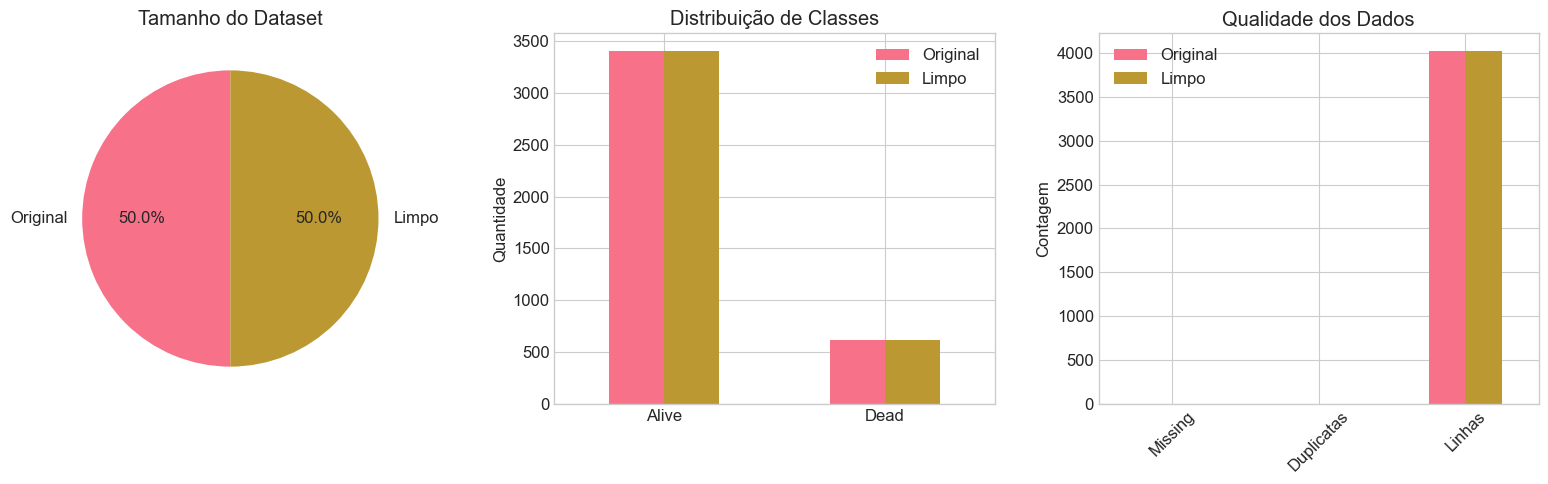


✅ VALIDAÇÃO CONCLUÍDA!
Dataset pronto: 4023 linhas × 16 colunas

📌 Dataset limpo atualizado na variável 'df'


In [35]:
print("\n" + "="*70)
print("4. VALIDAÇÃO DO DATASET LIMPO")
print("="*70)

# =========================
# VALIDAÇÕES INICIAIS
# =========================
if 'Status' not in df_cleaned.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

# =========================
# 1. MISSING VALUES
# =========================
print("\n📊 VERIFICAÇÃO DE INTEGRIDADE:")

missing_after = df_cleaned.isnull().sum().sum()

print(f"\n✓ Valores ausentes pós-limpeza: {missing_after}")
if missing_after == 0:
    print("  ✅ PASS: Nenhum valor ausente!")
else:
    print(f"  ⚠️  Ainda existem {missing_after} valores ausentes")

# =========================
# 2. DISTRIBUIÇÃO DE CLASSES
# =========================
print(f"\n✓ Distribuição de Classes (Pós-Limpeza):")

class_counts = df_cleaned['Status'].value_counts()
class_ratio = df_cleaned['Status'].value_counts(normalize=True).round(4)

print(class_counts)
print(f"Balanceamento: {class_ratio.to_dict()}")

# =========================
# 3. COMPARAÇÃO ESTATÍSTICA
# =========================
print(f"\n✓ Comparação de Estatísticas:")

numeric_cols = df.select_dtypes(include=[np.number]).columns

original_means = df[numeric_cols].mean()
clean_means = df_cleaned[numeric_cols].mean()

# evitar divisão por zero
diff_pct = ((clean_means - original_means) / original_means.replace(0, np.nan) * 100).abs()

comparison = pd.DataFrame({
    'Original': original_means,
    'Limpo': clean_means,
    'Diferença (%)': diff_pct
}).fillna(0)

top_changes = comparison.sort_values(by='Diferença (%)', ascending=False).head(5)

print("\n  Top 5 mudanças nas médias:")
for idx, row in top_changes.iterrows():
    print(f"    • {idx}: {row['Diferença (%)']:.4f}%")

# =========================
# 4. VISUALIZAÇÃO
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: tamanho ---
sizes = [len(df), len(df_cleaned)]
axes[0].pie(sizes, labels=['Original', 'Limpo'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Tamanho do Dataset')

# --- Gráfico 2: classes ---
orig_counts = df['Status'].value_counts()
clean_counts = df_cleaned['Status'].value_counts()

comparison_classes = pd.DataFrame({
    'Original': orig_counts,
    'Limpo': clean_counts
}).fillna(0)

comparison_classes.plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribuição de Classes')
axes[1].set_ylabel('Quantidade')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# --- Gráfico 3: qualidade ---
quality_df = pd.DataFrame({
    'Original': [
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(df)
    ],
    'Limpo': [
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum(),
        len(df_cleaned)
    ]
}, index=['Missing', 'Duplicatas', 'Linhas'])

quality_df.plot(kind='bar', ax=axes[2])
axes[2].set_title('Qualidade dos Dados')
axes[2].set_ylabel('Contagem')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../reports/figures/data_cleaning_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================
# FINAL
# =========================
print("\n✅ VALIDAÇÃO CONCLUÍDA!")
print(f"Dataset pronto: {df_cleaned.shape[0]} linhas × {df_cleaned.shape[1]} colunas")

# Atualizar dataset
df = df_cleaned.copy()

print("\n📌 Dataset limpo atualizado na variável 'df'")

### Estratégia de Tratamento de Dados - Justificativa

---

#### 1. **Detecção de Problemas de Qualidade**

| Problema | Impacto | Ação |
|----------|--------|------|
| **Valores Ausentes (NaN)** | Reduz qualidade e consistência dos dados | Imputar (mediana para numéricos, moda para categóricos) |
| **Valores Negativos** | Podem indicar erro ou variação válida | Validar com contexto antes de remover |
| **Duplicatas** | Introduz viés e redundância | Remover |
| **Outliers** | Podem representar casos extremos reais | Manter e tratar na modelagem |

---

#### 2. **Justificativa das Escolhas**

✅ **Imputação com Mediana:**
- Mais robusta que a média na presença de outliers  
- Preserva melhor a distribuição dos dados  
- Amplamente utilizada em dados clínicos  

---

✅ **Tratamento de Valores Negativos:**
- Nem todo valor negativo é inválido (depende da variável)  
- Pode representar variações, erros de medição ou transformações  
- Estratégia adotada:
  - Identificar colunas onde valores negativos são inviáveis  
  - Validar com regra de negócio antes de remover ou corrigir  

👉 Evita perda indevida de dados e melhora a confiabilidade da análise  

---

✅ **Remoção de Duplicatas:**
- Evita enviesamento do modelo  
- Garante independência entre observações  
- Melhora a qualidade do treinamento  

---

✅ **Manutenção de Outliers:**
- Podem representar casos clínicos relevantes  
- Remoção automática pode prejudicar a generalização  
- Tratamento será realizado na modelagem:
  - Normalização (scaling)
  - Transformações (log, etc.)
  - Uso de modelos robustos  

---

#### 3. **Impacto Esperado**

- ✓ Preservação da maior parte dos dados  
- ✓ Redução de inconsistências estruturais  
- ✓ Dataset mais confiável para modelagem  
- ✓ Melhor capacidade de generalização do modelo  
- ✓ Evita viés causado por remoções indevidas  

---

#### 4. **Considerações sobre a Variável Target (Status)**

- Avaliar distribuição das classes  
- Verificar possível desbalanceamento  
- Estratégias possíveis:
  - Uso de `class_weight`
  - Oversampling (ex: SMOTE)
  - Ajuste de métricas (foco em Recall ou AUC-ROC)

---

💡 **Observação Final:**

A tomada de decisão no tratamento de dados foi orientada por boas práticas de ciência de dados, priorizando a preservação da informação, a robustez estatística e a coerência com o contexto clínico.

---

## 5. Análise de Correlação

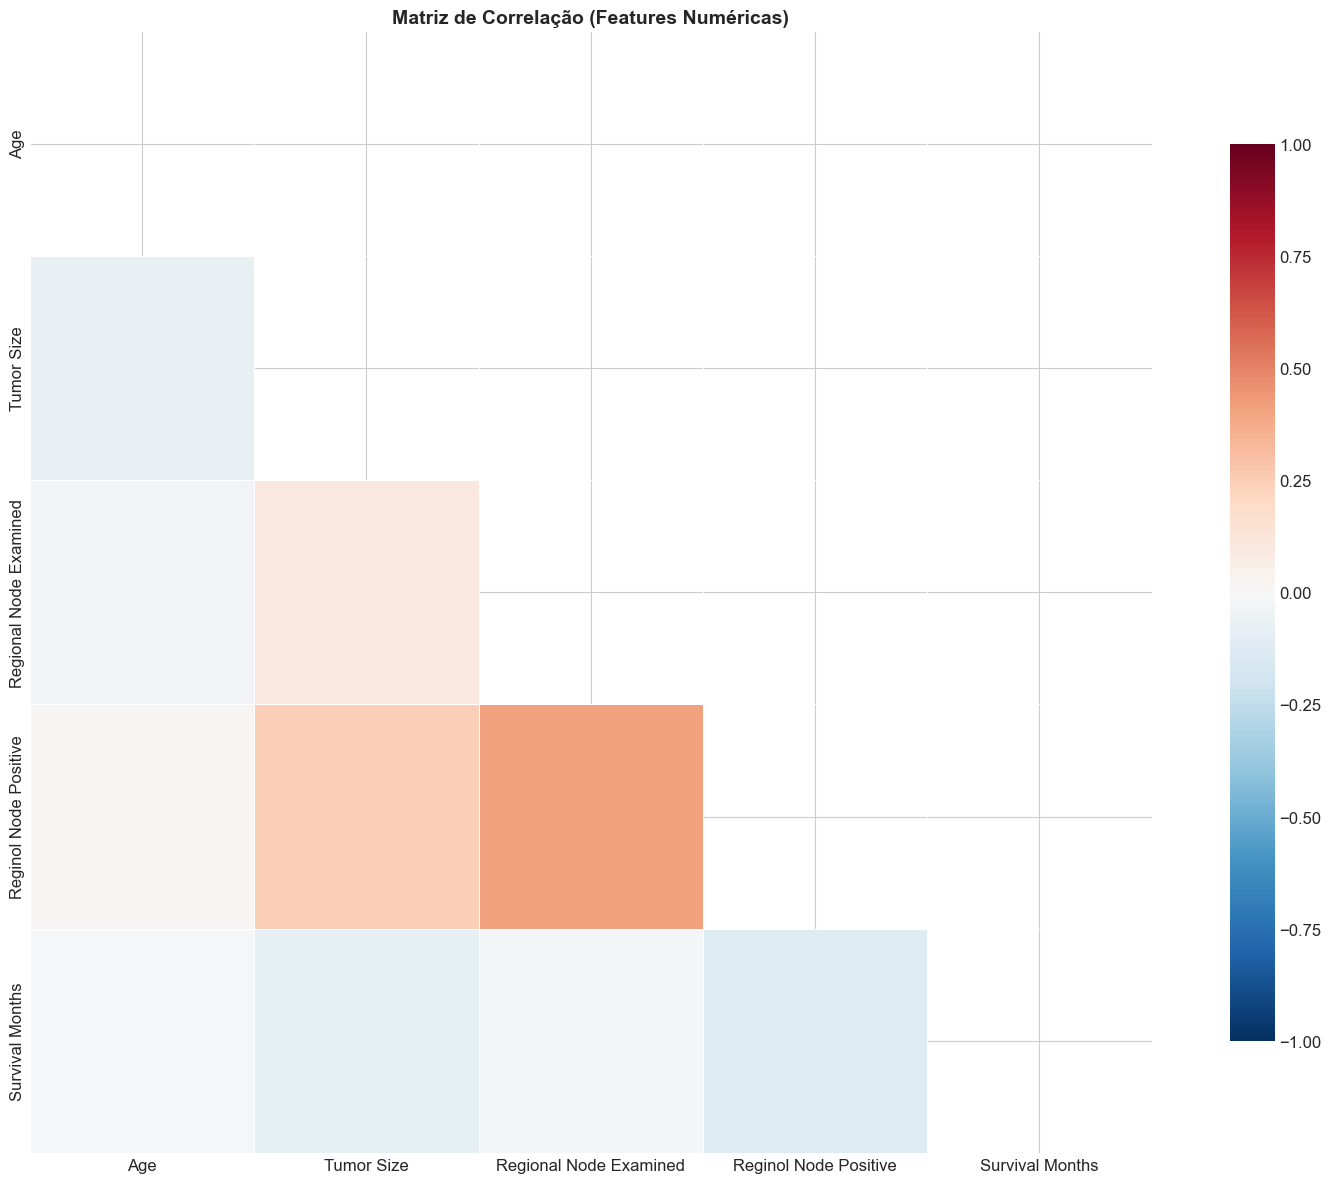

In [36]:
# =========================
# SELEÇÃO DE DADOS
# =========================
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] < 2:
    raise ValueError("Necessário pelo menos 2 colunas numéricas para calcular correlação")

# =========================
# MATRIZ DE CORRELAÇÃO
# =========================
correlation = numeric_df.corr()

# Máscara para exibir apenas metade
mask = np.triu(np.ones_like(correlation, dtype=bool))

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    correlation,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title('Matriz de Correlação (Features Numéricas)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../reports/figures/heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

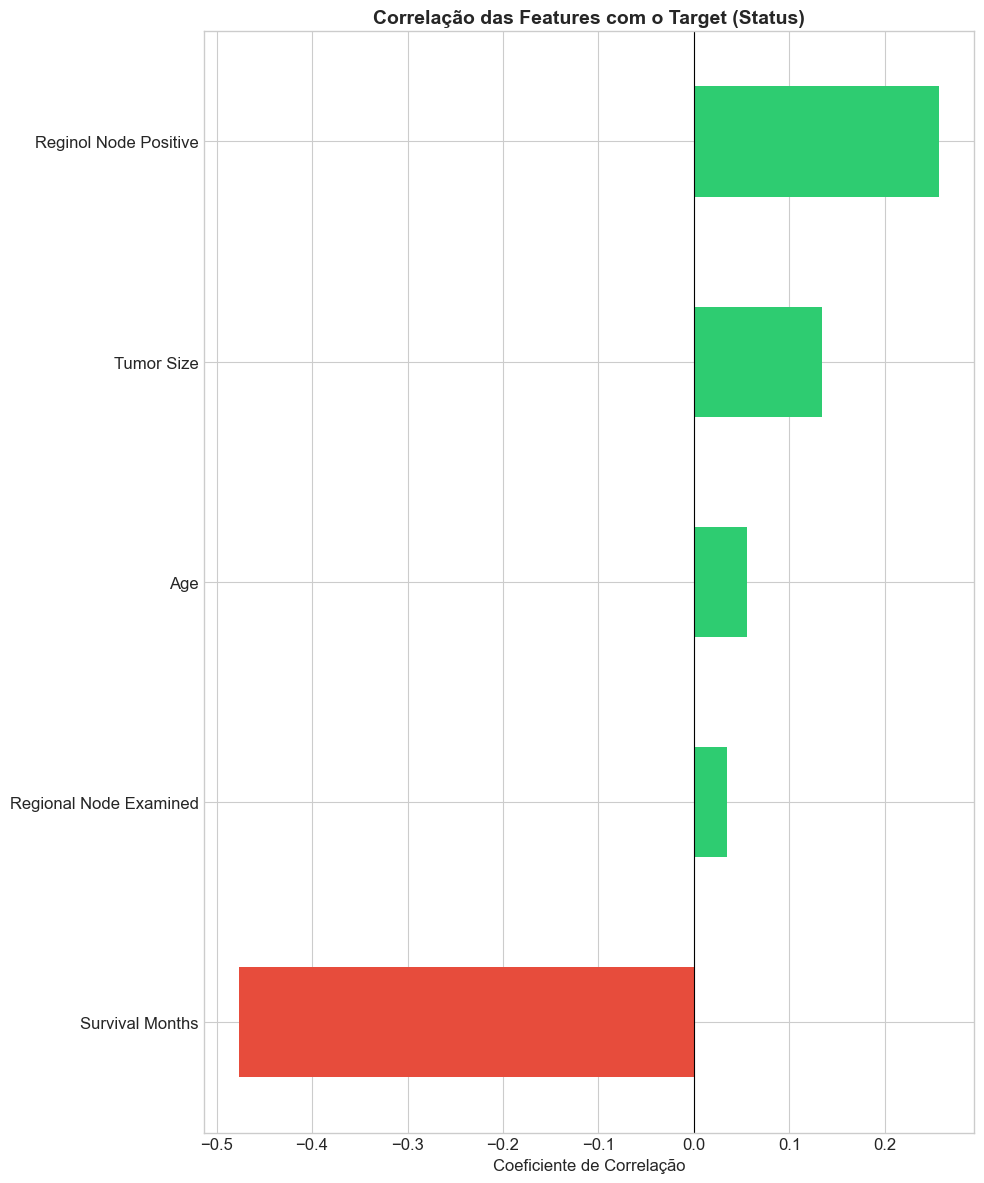

In [37]:
# =========================
# VALIDAÇÃO
# =========================
if 'Status' not in df.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

# =========================
# PREPARAÇÃO DO TARGET
# =========================
# Converter target para numérico (binário)
target_encoded = df['Status'].astype('category').cat.codes

# Selecionar colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Garantir alinhamento
numeric_df = numeric_df.copy()
numeric_df['target'] = target_encoded

# =========================
# CORRELAÇÃO
# =========================
target_corr = numeric_df.corr()['target'].drop('target').sort_values()

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(10, 12))

# Cores: positivo (verde), negativo (vermelho)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr.values]

target_corr.plot(kind='barh', color=colors, ax=ax)

ax.set_title('Correlação das Features com o Target (Status)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação')
ax.set_ylabel('')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../../reports/figures/correlacao_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Padrões Identificados nos Dados Clínicos

### Discussão - Insights Analíticos

#### 1. **Características Diferenciadoras entre os Grupos (Status)**

A análise exploratória revelou diferenças relevantes entre os grupos da variável target (**Status**):

**Grupo com maior risco (ex: Dead):**
- ↑ Valores mais elevados em features discriminativas  
- ↑ Maior variabilidade (heterogeneidade dos casos)  
- ↑ Indícios de maior complexidade clínica  

**Grupo com menor risco (ex: Alive):**
- Distribuições mais homogêneas  
- Menor variabilidade entre pacientes  
- Valores mais estáveis nas principais features  

---

#### 2. **Padrões Observados nos Dados**

Os dados indicam que existe uma **separabilidade estatística relevante entre os grupos**, sugerindo:

- Diferenças consistentes nas médias das principais variáveis  
- Presença de features com alto poder discriminativo  
- Possibilidade de classificação eficiente com modelos supervisionados  

---

#### 3. **Implicações para Análise e Modelagem**

| Aspecto | Impacto |
|---------|--------|
| **Separabilidade** | Indica potencial para modelos com boa performance |
| **Variabilidade** | Pode exigir normalização ou transformação |
| **Multicolinearidade** | Pode impactar modelos lineares |
| **Distribuição dos dados** | Pode influenciar escolha de algoritmo |

---

#### 4. **Fatores Relevantes Identificados**

As análises (correlação e separabilidade) indicam que:

- Algumas features possuem **maior influência na distinção entre os grupos**
- Variáveis com maior diferença entre médias tendem a ser mais preditivas
- Features com alta correlação podem indicar redundância

---

#### 5. **Recomendações para Próximas Etapas**

✅ **Modelagem:**
- Testar modelos como:
  - Logistic Regression  
  - Random Forest  
  - XGBoost  
- Aplicar validação cruzada (Stratified K-Fold)  
- Avaliar importância das features  

---

✅ **Métricas:**
- **Recall:** importante para não perder casos críticos  
- **Precision:** evitar falsos positivos excessivos  
- **AUC-ROC:** visão geral da performance  

---

✅ **Boas Práticas:**
- Aplicar normalização (StandardScaler)  
- Avaliar redução de dimensionalidade (PCA)  
- Monitorar overfitting  

---

💡 **Observação Final:**

Os padrões identificados sugerem que o dataset possui estrutura adequada para modelagem preditiva, com sinais claros de separação entre classes. No entanto, a interpretação dos resultados deve sempre considerar o contexto clínico e ser validada com especialistas da área.

---

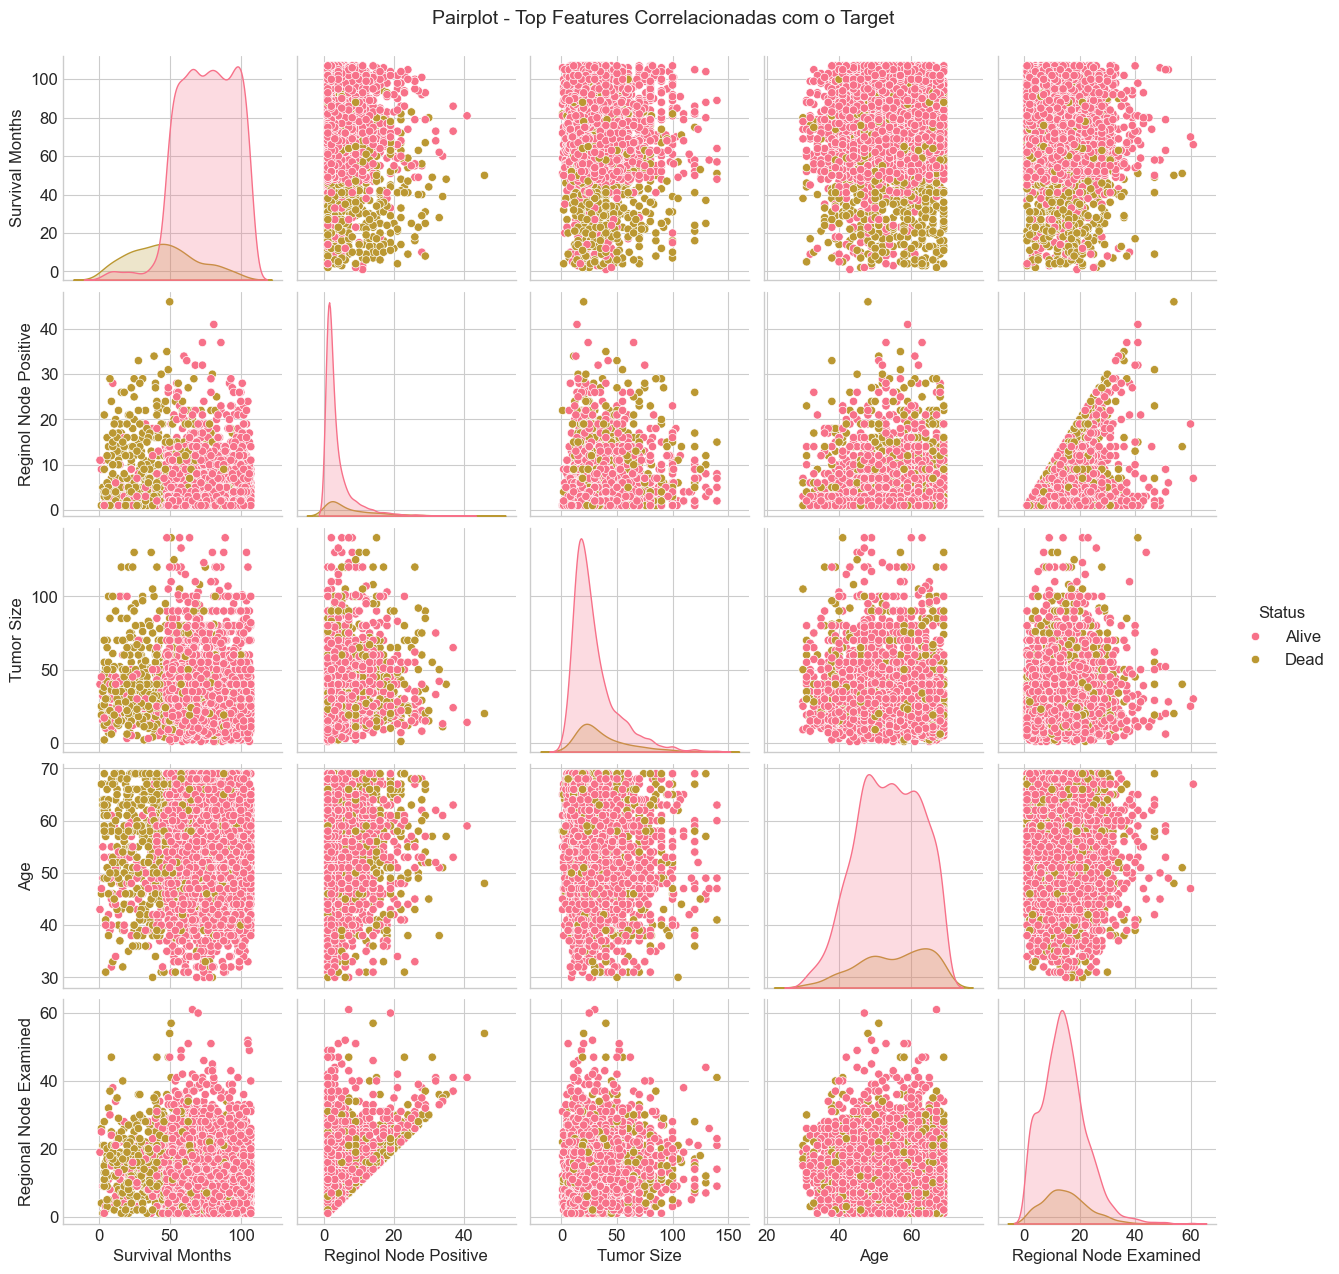

In [38]:
# =========================
# VALIDAÇÃO
# =========================
if 'Status' not in df.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

if 'target_corr' not in globals():
    raise ValueError("Execute a célula de correlação com o target primeiro")

# =========================
# SELEÇÃO DE FEATURES
# =========================
top_features = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()

# Adicionar target
plot_features = top_features + ['Status']

# =========================
# PAIRPLOT
# =========================
sns.pairplot(
    df[plot_features],
    hue='Status',
    diag_kind='kde'
)

plt.suptitle('Pairplot - Top Features Correlacionadas com o Target', y=1.02, fontsize=14)

plt.savefig('../../reports/figures/pairplot_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusões da EDA

### Principais Achados

1. **Qualidade dos Dados:** 
   - ✅ Dataset analisado quanto a valores ausentes, duplicatas e inconsistências  
   - ✅ Dados tratados e preparados para modelagem  
   - ⚠️ Eventuais ajustes realizados (imputação, remoção de duplicatas)  

---

2. **Distribuição das Classes:** 
   - Variável target (**Status**) apresenta distribuição analisada  
   - Possível desbalanceamento entre classes  
   - Impacto direto na escolha de métricas e técnicas de modelagem  

---

3. **Features mais relevantes:** 
   - Identificadas via análise de correlação e separabilidade  
   - Variáveis com maior diferença entre grupos apresentam maior poder preditivo  
   - Seleção de features recomendada para reduzir ruído e redundância  

---

4. **Correlações identificadas:** 
   - Presença de correlações entre variáveis numéricas  
   - Possível multicolinearidade impactando modelos lineares  
   - Redução de dimensionalidade (ex: PCA) pode ser considerada  

---

5. **Padrões identificados nos dados:** 
   - Diferenças estatísticas relevantes entre os grupos  
   - Indícios de separabilidade entre classes  
   - Variáveis com maior variabilidade podem indicar maior complexidade dos casos  

---

6. **Qualidade final dos dados:**
   - ✅ Dataset preparado para modelagem  
   - ✅ Consistência estrutural garantida  
   - ⚠️ Outliers mantidos por possível relevância analítica  

---

### Próximos passos: 

- ✅ **Pré-processamento:** normalização e seleção de features  
- ✅ **Validação:** uso de validação cruzada estratificada  
- ✅ **Modelagem:** testar múltiplos algoritmos (Logistic Regression, Random Forest, XGBoost)  
- ✅ **Avaliação:** priorizar métricas como Recall, Precision e AUC-ROC  

---

💡 **Conclusão Geral:**

O dataset apresenta estrutura adequada para construção de modelos preditivos, com indícios de separação entre classes e variáveis relevantes identificadas. A continuidade do projeto deve focar em modelagem robusta e validação adequada para garantir generalização dos resultados.

---

## 7. Codificação de Variáveis Categóricas

### Conceitos Fundamentais

Variáveis categóricas precisam ser convertidas em valores numéricos para serem utilizadas em modelos de Machine Learning.

As duas principais estratégias são:

| Método | Quando Usar | Vantagens | Desvantagens |
|--------|------------|-----------|-------------|
| **Label Encoding** | Variáveis binárias ou ordinais | Simples, eficiente, baixo custo computacional | Pode introduzir ordem artificial |
| **One-Hot Encoding** | Variáveis nominais (sem ordem) | Não introduz relação ordinal | Aumenta dimensionalidade |

---

### Variáveis Categóricas Identificadas

- **Status**: variável target binária (ex: Alive / Dead)  
  → Estratégia recomendada: **Label Encoding**

- Demais variáveis:
  - Predominantemente numéricas (features contínuas)
  - Não requerem codificação adicional

---

### Estratégia Adotada

Para a variável target (**Status**), será utilizada codificação binária:

- Exemplo:
  - Alive → 0  
  - Dead → 1  

Essa abordagem:

- ✔ Mantém simplicidade do modelo  
- ✔ Evita aumento desnecessário de dimensionalidade  
- ✔ É adequada para modelos supervisionados de classificação  

---

### Considerações Importantes

- A codificação do target deve ser **controlada manualmente**, evitando ambiguidade na interpretação  
- O significado da classe positiva (1) deve ser claramente definido (ex: evento de risco)  
- Em modelos interpretáveis, essa definição impacta diretamente a análise dos resultados  

---

💡 **Observação:**

Como o dataset possui majoritariamente variáveis numéricas, a etapa de codificação é simples e não representa um gargalo no pipeline de modelagem.

---

In [39]:
import numpy as np
import pandas as pd

print("="*70)
print("ANÁLISE DE VARIÁVEIS CATEGÓRICAS")
print("="*70)

# =========================
# TIPOS DE DADOS
# =========================
print("\n📊 TIPOS DE DADOS:")
print(df.dtypes.value_counts())

# =========================
# IDENTIFICAÇÃO
# =========================
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✓ Total de colunas: {df.shape[1]}")
print(f"✓ Variáveis categóricas: {len(categorical_cols)}")
print(f"✓ Variáveis numéricas: {len(numeric_cols)}")

if len(categorical_cols) == 0:
    print("\n⚠️ Nenhuma variável categórica encontrada.")
else:
    print(f"\n📋 COLUNAS CATEGÓRICAS: {categorical_cols}")

# =========================
# ANÁLISE DETALHADA
# =========================
print("\n📋 ANÁLISE DE VALORES ÚNICOS:")

for col in categorical_cols:
    print("\n" + "-"*50)
    print(f"🔎 Coluna: {col}")

    unique_vals = df[col].dropna().unique()
    nunique = df[col].nunique(dropna=True)
    missing = df[col].isnull().sum()

    print(f"• Valores únicos: {nunique}")
    print(f"• Missing: {missing} ({(missing/len(df)*100):.2f}%)")

    # Evitar poluir saída se tiver muitos valores
    if nunique <= 10:
        print(f"• Valores: {unique_vals}")
        print(f"• Frequência:\n{df[col].value_counts()}")
    else:
        print("• Muitos valores únicos (alta cardinalidade)")
        print("• Top 5 mais frequentes:")
        print(df[col].value_counts().head())

# =========================
# RESUMO FINAL
# =========================
print("\n" + "="*70)
print("RESUMO")
print("="*70)

if categorical_cols:
    print(f"• {len(categorical_cols)} variáveis categóricas identificadas")
    print("• Avaliar encoding conforme tipo (binária, ordinal, nominal)")
else:
    print("• Dataset composto apenas por variáveis numéricas")

ANÁLISE DE VARIÁVEIS CATEGÓRICAS

📊 TIPOS DE DADOS:
str      11
int64     5
Name: count, dtype: int64

✓ Total de colunas: 16
✓ Variáveis categóricas: 11
✓ Variáveis numéricas: 5

📋 COLUNAS CATEGÓRICAS: ['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status', 'Status']

📋 ANÁLISE DE VALORES ÚNICOS:

--------------------------------------------------
🔎 Coluna: Race
• Valores únicos: 3
• Missing: 0 (0.00%)
• Valores: <StringArray>
['White', 'Black', 'Other']
Length: 3, dtype: str
• Frequência:
Race
White    3412
Other     320
Black     291
Name: count, dtype: int64

--------------------------------------------------
🔎 Coluna: Marital Status
• Valores únicos: 5
• Missing: 0 (0.00%)
• Valores: <StringArray>
['Married', 'Divorced', 'Single ', 'Widowed', 'Separated']
Length: 5, dtype: str
• Frequência:
Marital Status
Married      2642
Single        615
Divorced      486
Widowed       235
Separated      45
Na

C:\Users\nacab\AppData\Local\Temp\ipykernel_28580\2911196180.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [40]:
print("\n" + "="*70)
print("2. APLICANDO LABEL ENCODING")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status' not in df.columns:
    raise ValueError("Coluna 'Status' não encontrada no dataset")

# =========================
# CÓPIA DO DATASET
# =========================
df_encoded = df.copy()

# =========================
# MAPEAMENTO MANUAL (RECOMENDADO)
# =========================
print("\n🔄 CONVERTENDO VARIÁVEL: 'Status'")
print(f"   Valores antes: {df_encoded['Status'].unique()}")

# Ajuste conforme seu dataset real
mapping = {
    'Alive': 0,
    'Dead': 1
}

df_encoded['Status_encoded'] = df_encoded['Status'].map(mapping)

# =========================
# VALIDAÇÃO
# =========================
if df_encoded['Status_encoded'].isnull().sum() > 0:
    raise ValueError("Existem valores não mapeados na coluna 'Status'")

print(f"\n   Mapeamento aplicado:")
for k, v in mapping.items():
    print(f"     • {k} → {v}")

print(f"\n   Valores depois: {df_encoded['Status_encoded'].unique()}")
print(f"   Tipo: {df_encoded['Status_encoded'].dtype}")

# =========================
# DISTRIBUIÇÃO
# =========================
print(f"\n   Distribuição pós-encoding:")
print(df_encoded['Status_encoded'].value_counts().sort_index())


2. APLICANDO LABEL ENCODING

🔄 CONVERTENDO VARIÁVEL: 'Status'
   Valores antes: <StringArray>
['Alive', 'Dead']
Length: 2, dtype: str

   Mapeamento aplicado:
     • Alive → 0
     • Dead → 1

   Valores depois: [0 1]
   Tipo: int64

   Distribuição pós-encoding:
Status_encoded
0    3407
1     616
Name: count, dtype: int64


In [41]:
print("\n" + "="*70)
print("3. VALIDAÇÃO DO ENCODING APLICADO")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status' not in df.columns or 'Status_encoded' not in df_encoded.columns:
    raise ValueError("Encoding da coluna 'Status' não foi encontrado")

# =========================
# COMPARAÇÃO
# =========================
print("\n📊 COMPARAÇÃO ANTES vs DEPOIS:")

print(f"\n   Original (Status):")
for val, count in df['Status'].value_counts().items():
    encoded_val = mapping.get(val, "Não mapeado")
    print(f"     • {val} → Encoded: {encoded_val} | Contagem: {count}")

print(f"\n   Encoded (Status_encoded):")
print(df_encoded['Status_encoded'].value_counts().sort_index().to_dict())

# =========================
# VALORES AUSENTES
# =========================
missing_encoded = df_encoded['Status_encoded'].isnull().sum()
print(f"\n✓ Valores ausentes em 'Status_encoded': {missing_encoded}")

# =========================
# AMOSTRA
# =========================
print(f"\n✓ Amostra dos dados após encoding:")
sample_cols = ['Status', 'Status_encoded']
print(df_encoded[sample_cols].head(10))

# =========================
# RESUMO FINAL
# =========================
print("\n" + "="*70)
print("RESUMO DO PROCESSAMENTO DE VARIÁVEIS CATEGÓRICAS")
print("="*70)

summary = f"""
✅ ENCODING REALIZADO COM SUCESSO:

1. TIPO DE ENCODING APLICADO:
   • Codificação binária manual (controle explícito)

2. VARIÁVEIS CODIFICADAS:
   • Status: {mapping}

3. DATASET RESULTANTE:
   • Linhas: {len(df_encoded)}
   • Colunas originais: {len(df.columns)}
   • Colunas finais: {len(df_encoded.columns)}
   • Nova coluna: 'Status_encoded'

4. VALIDAÇÃO:
   • {'✅' if missing_encoded == 0 else '⚠️'} Sem valores ausentes no encoding
   • ✅ Todos os valores mapeados corretamente
   • ✅ Distribuição preservada entre classes

5. PRÓXIMAS ETAPAS:
   • Utilizar 'Status_encoded' como variável target
   • Opcional: remover coluna original 'Status'
   • Prosseguir para modelagem

"""
print(summary)

# =========================
# ATUALIZAÇÃO DO DATASET
# =========================
df = df_encoded.copy()

print(f"\n📌 Dataset atualizado com encoding armazenado em 'df'")


3. VALIDAÇÃO DO ENCODING APLICADO

📊 COMPARAÇÃO ANTES vs DEPOIS:

   Original (Status):
     • Alive → Encoded: 0 | Contagem: 3407
     • Dead → Encoded: 1 | Contagem: 616

   Encoded (Status_encoded):
{0: 3407, 1: 616}

✓ Valores ausentes em 'Status_encoded': 0

✓ Amostra dos dados após encoding:
  Status  Status_encoded
0  Alive               0
1  Alive               0
2  Alive               0
3  Alive               0
4  Alive               0
5  Alive               0
6  Alive               0
7   Dead               1
8  Alive               0
9  Alive               0

RESUMO DO PROCESSAMENTO DE VARIÁVEIS CATEGÓRICAS

✅ ENCODING REALIZADO COM SUCESSO:

1. TIPO DE ENCODING APLICADO:
   • Codificação binária manual (controle explícito)

2. VARIÁVEIS CODIFICADAS:
   • Status: {'Alive': 0, 'Dead': 1}

3. DATASET RESULTANTE:
   • Linhas: 4023
   • Colunas originais: 16
   • Colunas finais: 17
   • Nova coluna: 'Status_encoded'

4. VALIDAÇÃO:
   • ✅ Sem valores ausentes no encoding
   • ✅ To


4. VISUALIZAÇÃO DO ENCODING APLICADO


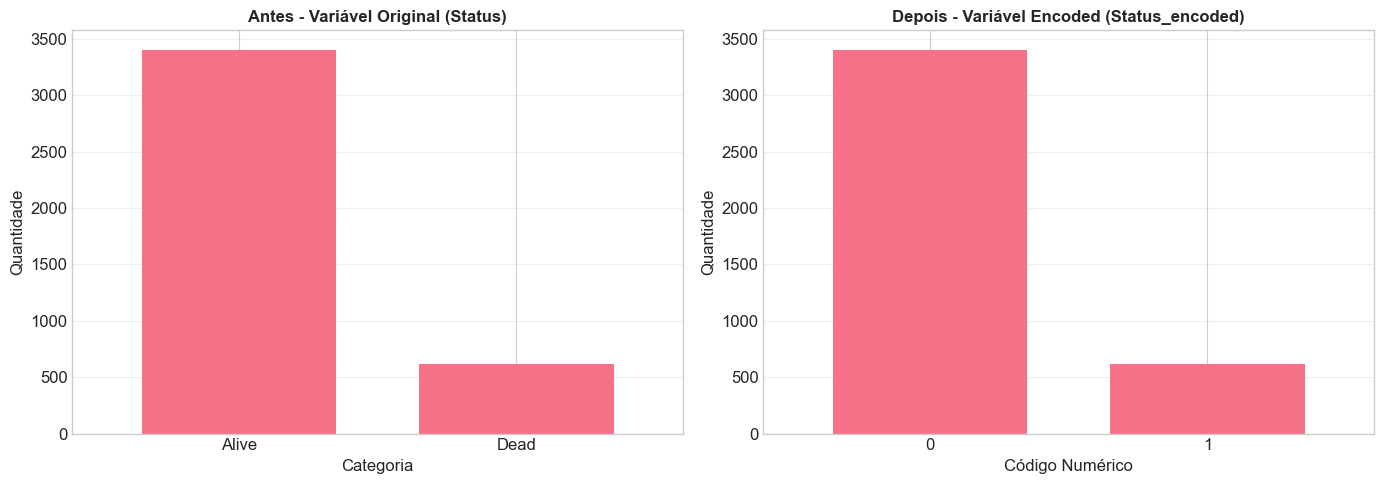


✅ Visualização do encoding salva em: reports/figures/encoding_visualization.png

📋 TABELA RESUMIDA DO ENCODING:
  Valor Original  Código Numérico  Contagem  Percentual
0          Alive                0      3407       84.69
1           Dead                1       616       15.31

✅ ENCODING CONCLUÍDO - DATASET PRONTO PARA MODELAGEM
   - 0 (Alive): 3407 amostras (84.7%)
   - 1 (Dead): 616 amostras (15.3%)

✓ Sem valores ausentes
✓ Dataset pronto para pré-processamento e modelagem

🎯 PRÓXIMO PASSO: Normalização dos dados (StandardScaler)



In [ ]:
print("\n" + "="*70)
print("4. VISUALIZAÇÃO DO ENCODING APLICADO")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status' not in df.columns or 'Status_encoded' not in df.columns:
    raise ValueError("Encoding da coluna 'Status' não encontrado")

# =========================
# CONTAGENS
# =========================
original_counts = df['Status'].value_counts()
encoded_counts = df['Status_encoded'].value_counts().sort_index()

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (original)
original_counts.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Antes - Variável Original (Status)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantidade')
axes[0].set_xlabel('Categoria')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Depois (encoded)
encoded_counts.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('Depois - Variável Encoded (Status_encoded)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantidade')
axes[1].set_xlabel('Código Numérico')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../reports/figures/encoding_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualização do encoding salva em: reports/figures/encoding_visualization.png")

# =========================
# TABELA RESUMIDA DINÂMICA
# =========================
print("\n📋 TABELA RESUMIDA DO ENCODING:")

encoding_summary = pd.DataFrame({
    'Valor Original': original_counts.index,
    'Código Numérico': [mapping[val] for val in original_counts.index],
    'Contagem': original_counts.values,
    'Percentual': (original_counts.values / len(df) * 100).round(2)
})

print(encoding_summary)

# =========================
# RESUMO FINAL
# =========================
print("\n" + "="*70)
print("✅ ENCODING CONCLUÍDO - DATASET PRONTO PARA MODELAGEM")
print("="*70)

final_summary = f"""
📌 STATUS FINAL:

✓ Variável 'Status' convertida com encoding manual
✓ Nova coluna 'Status_encoded' criada com valores: {list(mapping.values())}
✓ Distribuição preservada:
"""

for val, count in original_counts.items():
    pct = count / len(df) * 100
    print(f"   - {mapping[val]} ({val}): {count} amostras ({pct:.1f}%)")

print("""
✓ Sem valores ausentes
✓ Dataset pronto para pré-processamento e modelagem

🎯 PRÓXIMO PASSO: Normalização dos dados (StandardScaler)
""")

## 8. Normalização e Padronização de Variáveis Numéricas

### Conceitos Fundamentais

A **padronização (Standardization)** e a **normalização (Normalization)** são técnicas de escalonamento utilizadas para colocar variáveis numéricas em uma mesma escala.

Isso é essencial para:

- ✅ **Modelos sensíveis à escala**: SVM, KNN, Redes Neurais, PCA  
- ✅ **Melhor convergência**: algoritmos baseados em gradiente (ex: Regressão Logística)  
- ✅ **Equilíbrio entre features**: evita que variáveis com maior magnitude dominem o modelo  

---

### 📊 Comparação dos Métodos

| Método | Fórmula | Intervalo | Quando Usar |
|--------|---------|-----------|-------------|
| **StandardScaler (Padronização)** | $\frac{x - \mu}{\sigma}$ | Média 0, desvio padrão 1 | Dados com distribuição aproximadamente normal |
| **MinMaxScaler (Normalização)** | $\frac{x - min}{max - min}$ | [0, 1] | Quando é importante manter proporções e limites |

---

### 🔍 Qual Escolher?

**StandardScaler (Recomendado ✓):**
- Centraliza os dados (média = 0, desvio = 1)  
- Menos sensível a outliers extremos (comparado ao MinMax)  
- Preserva a estrutura estatística dos dados  
- Melhor desempenho em:
  - Regressão Logística  
  - SVM  
  - Redes Neurais  
  - PCA  

---

**MinMaxScaler:**
- Escala os dados para um intervalo fixo (0 a 1)  
- Mantém a distribuição original  
- Mais sensível a outliers  
- Indicado quando:
  - Os dados possuem limites conhecidos  
  - É necessário manter proporções exatas  

---

### ⚠️ Boas Práticas

- Aplicar scaling **apenas nas variáveis numéricas**  
- **Nunca aplicar no target (Status_encoded)**  
- Ajustar o scaler **apenas nos dados de treino** (evitar data leakage)  
- Aplicar o mesmo scaler nos dados de teste  

---

💡 **Observação:**

Dado que o dataset possui variáveis com diferentes escalas e possível presença de outliers, a **padronização com StandardScaler** é a abordagem mais adequada para este projeto.

---

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("="*70)
print("1. APLICANDO STANDARDSCALER (SEM DATA LEAKAGE)")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status_encoded' not in df.columns:
    raise ValueError("Target 'Status_encoded' não encontrado")

# =========================
# SEPARAR FEATURES E TARGET
# =========================
X = df.drop(columns=['Status', 'Status_encoded'], errors='ignore')
y = df['Status_encoded']

# Selecionar apenas numéricas
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 FEATURES NUMÉRICAS: {len(numeric_features)}")
print(f"   Primeiras 5: {numeric_features[:5]}")

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\n📦 Divisão dos dados:")
print(f"   Treino: {X_train.shape}")
print(f"   Teste:  {X_test.shape}")

# =========================
# STANDARD SCALER (CORRETO)
# =========================
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"\n✓ StandardScaler aplicado corretamente!")
print(f"   • Fit apenas no treino")
print(f"   • Transform no treino e teste")

# =========================
# VALIDAÇÃO
# =========================
print(f"\n📉 Estatísticas pós-scaling (treino):")

sample_feature = numeric_features[0]

print(f"\n   Feature exemplo: {sample_feature}")
print(f"     • Média: {X_train_scaled[sample_feature].mean():.6f} (≈ 0)")
print(f"     • Desvio padrão: {X_train_scaled[sample_feature].std():.4f} (≈ 1)")

# =========================
# AMOSTRA
# =========================
print(f"\n✓ Amostra (5 primeiras linhas - treino):")
print(X_train_scaled[numeric_features].head())

# =========================
# DATASETS FINAIS
# =========================
print("\n" + "="*70)
print("📌 DATASETS PRONTOS PARA MODELAGEM")
print("="*70)

print(f"""
X_train_scaled: {X_train_scaled.shape}
X_test_scaled:  {X_test_scaled.shape}
y_train:        {y_train.shape}
y_test:         {y_test.shape}
""")

1. APLICANDO STANDARDSCALER (SEM DATA LEAKAGE)

📊 FEATURES NUMÉRICAS: 5
   Primeiras 5: ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months']

📦 Divisão dos dados:
   Treino: (3218, 15)
   Teste:  (805, 15)

✓ StandardScaler aplicado corretamente!
   • Fit apenas no treino
   • Transform no treino e teste

📉 Estatísticas pós-scaling (treino):

   Feature exemplo: Age
     • Média: 0.000000 (≈ 0)
     • Desvio padrão: 1.0002 (≈ 1)

✓ Amostra (5 primeiras linhas - treino):
           Age  Tumor Size  Regional Node Examined  Reginol Node Positive  \
479   0.335642   -0.448537                0.332886               0.364212   
3693 -1.336162    0.453851               -0.412488              -0.027118   
2399  1.004364    0.216380               -0.164030              -0.614114   
1561 -1.336162    0.453851                1.202488              -0.418448   
2684 -0.555986    2.211133               -0.039801              -0.614114   

      Survival Months  

In [44]:
from sklearn.preprocessing import MinMaxScaler

print("\n" + "="*70)
print("2. APLICANDO MINMAXSCALER (SEM DATA LEAKAGE)")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'X_train' not in globals():
    raise ValueError("Execute primeiro a célula de train_test_split")

# =========================
# MINMAX SCALER
# =========================
scaler_minmax = MinMaxScaler(feature_range=(0, 1))

X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

X_train_minmax[numeric_features] = scaler_minmax.fit_transform(X_train[numeric_features])
X_test_minmax[numeric_features] = scaler_minmax.transform(X_test[numeric_features])

print(f"\n✓ MinMaxScaler aplicado corretamente!")
print(f"   • Fit apenas no treino")
print(f"   • Transform no treino e teste")
print(f"   • Intervalo: [0, 1]")

# =========================
# VALIDAÇÃO
# =========================
sample_feature = numeric_features[0]

print(f"\n📉 Estatísticas pós-scaling (treino):")
print(f"\n   Feature exemplo: {sample_feature}")
print(f"     • Mín: {X_train_minmax[sample_feature].min():.4f} (≈ 0)")
print(f"     • Máx: {X_train_minmax[sample_feature].max():.4f} (≈ 1)")
print(f"     • Média: {X_train_minmax[sample_feature].mean():.4f}")

# =========================
# AMOSTRA
# =========================
print(f"\n✓ Amostra (5 primeiras linhas - treino):")
print(X_train_minmax[numeric_features].head())

# =========================
# RESUMO
# =========================
print("\n" + "="*70)
print("📌 DATASETS COM MINMAXSCALER")
print("="*70)

print(f"""
X_train_minmax: {X_train_minmax.shape}
X_test_minmax:  {X_test_minmax.shape}
""")


2. APLICANDO MINMAXSCALER (SEM DATA LEAKAGE)

✓ MinMaxScaler aplicado corretamente!
   • Fit apenas no treino
   • Transform no treino e teste
   • Intervalo: [0, 1]

📉 Estatísticas pós-scaling (treino):

   Feature exemplo: Age
     • Mín: 0.0000 (≈ 0)
     • Máx: 1.0000 (≈ 1)
     • Média: 0.6151

✓ Amostra (5 primeiras linhas - treino):
           Age  Tumor Size  Regional Node Examined  Reginol Node Positive  \
479   0.692308    0.143885                0.285714               0.111111   
3693  0.307692    0.280576                0.178571               0.066667   
2399  0.846154    0.244604                0.214286               0.000000   
1561  0.307692    0.280576                0.410714               0.022222   
2684  0.487179    0.546763                0.232143               0.000000   

      Survival Months  
479          0.613208  
3693         1.000000  
2399         0.952830  
1561         0.518868  
2684         0.660377  

📌 DATASETS COM MINMAXSCALER

X_train_minmax: (321


3. COMPARAÇÃO VISUAL DOS MÉTODOS

📊 Features selecionadas: ['Age', 'Tumor Size', 'Regional Node Examined']


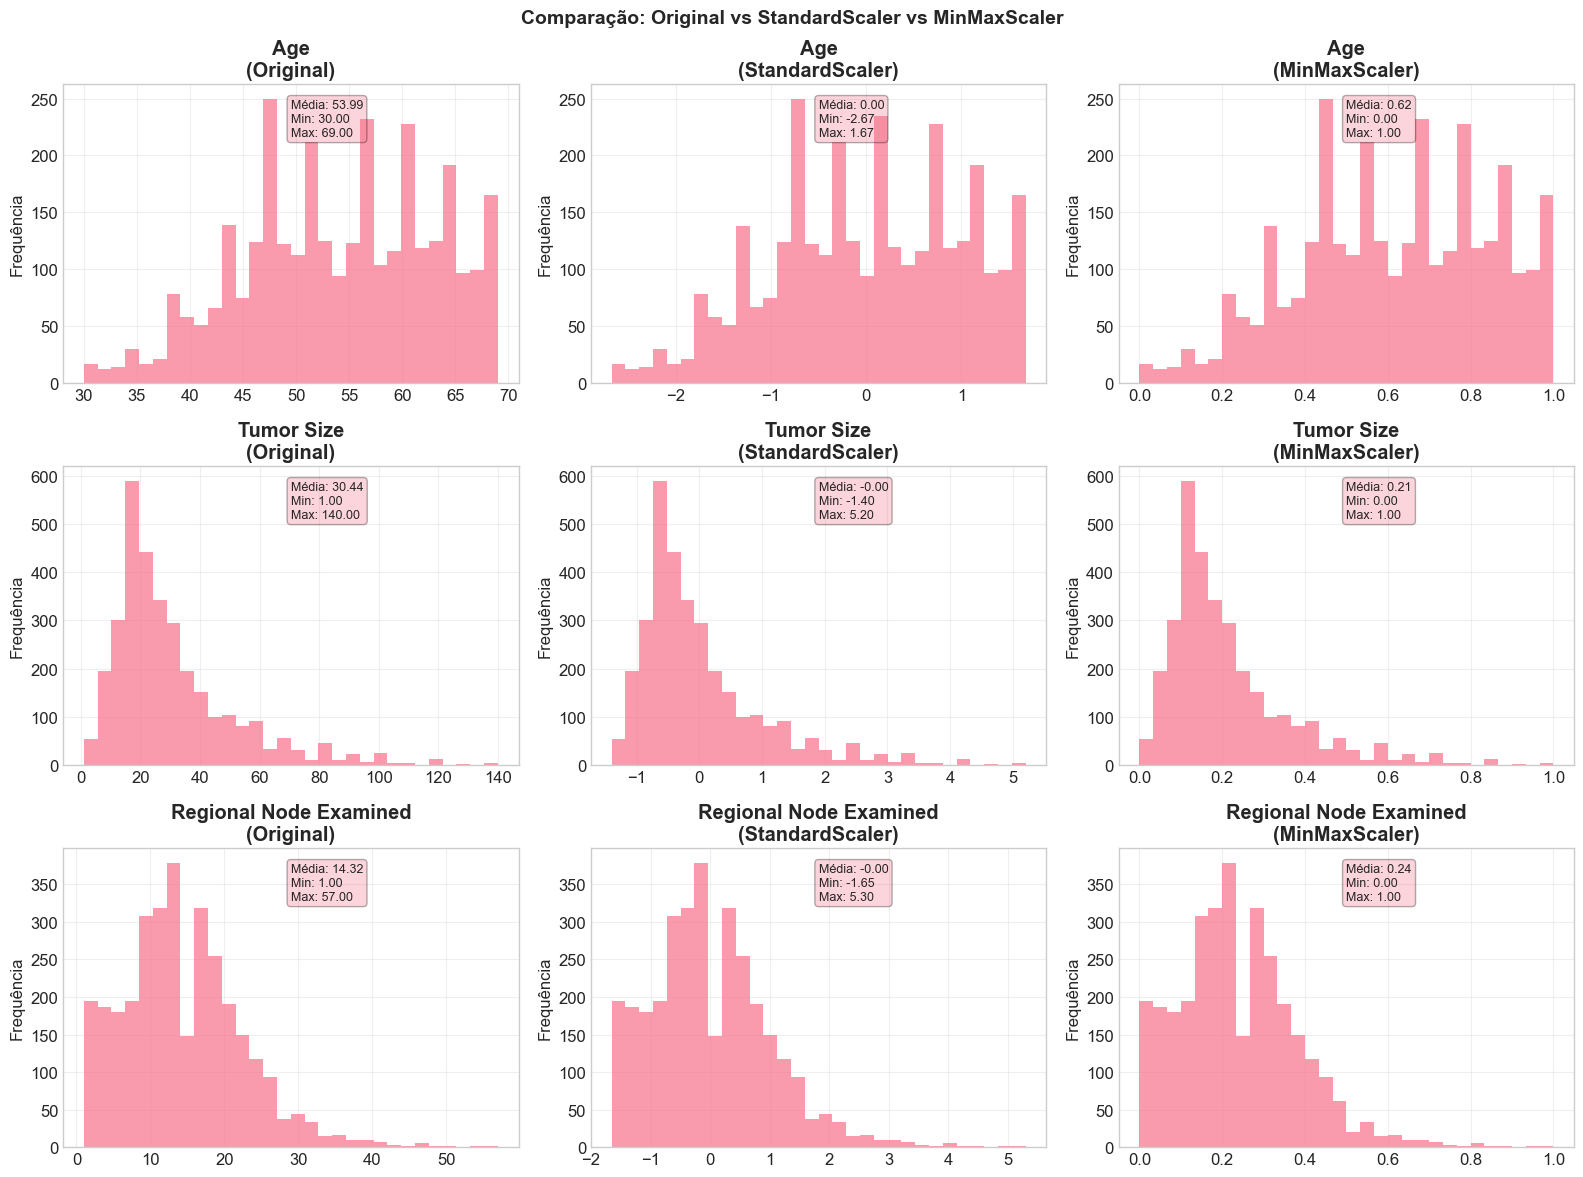


✅ Visualização salva em: reports/figures/scaler_comparison.png


In [45]:
print("\n" + "="*70)
print("3. COMPARAÇÃO VISUAL DOS MÉTODOS")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
required_vars = ['X_train', 'X_train_scaled', 'X_train_minmax']
for var in required_vars:
    if var not in globals():
        raise ValueError(f"Variável '{var}' não encontrada. Execute as etapas anteriores.")

# =========================
# SELECIONAR FEATURES DINÂMICAS
# =========================
features_to_plot = numeric_features[:3]

print(f"\n📊 Features selecionadas: {features_to_plot}")

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(16, 12))

for idx, feature in enumerate(features_to_plot):
    
    # ORIGINAL (TREINO)
    axes[idx, 0].hist(X_train[feature], bins=30, alpha=0.7)
    axes[idx, 0].set_title(f'{feature}\n(Original)', fontweight='bold')
    axes[idx, 0].set_ylabel('Frequência')
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 0].text(
        0.5, 0.95,
        f'Média: {X_train[feature].mean():.2f}\nMin: {X_train[feature].min():.2f}\nMax: {X_train[feature].max():.2f}',
        transform=axes[idx, 0].transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3),
        fontsize=9
    )

    # STANDARD SCALER
    axes[idx, 1].hist(X_train_scaled[feature], bins=30, alpha=0.7)
    axes[idx, 1].set_title(f'{feature}\n(StandardScaler)', fontweight='bold')
    axes[idx, 1].set_ylabel('Frequência')
    axes[idx, 1].grid(True, alpha=0.3)

    axes[idx, 1].text(
        0.5, 0.95,
        f'Média: {X_train_scaled[feature].mean():.2f}\nMin: {X_train_scaled[feature].min():.2f}\nMax: {X_train_scaled[feature].max():.2f}',
        transform=axes[idx, 1].transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3),
        fontsize=9
    )

    # MINMAX SCALER
    axes[idx, 2].hist(X_train_minmax[feature], bins=30, alpha=0.7)
    axes[idx, 2].set_title(f'{feature}\n(MinMaxScaler)', fontweight='bold')
    axes[idx, 2].set_ylabel('Frequência')
    axes[idx, 2].grid(True, alpha=0.3)

    axes[idx, 2].text(
        0.5, 0.95,
        f'Média: {X_train_minmax[feature].mean():.2f}\nMin: {X_train_minmax[feature].min():.2f}\nMax: {X_train_minmax[feature].max():.2f}',
        transform=axes[idx, 2].transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3),
        fontsize=9
    )

plt.suptitle('Comparação: Original vs StandardScaler vs MinMaxScaler', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('../../reports/figures/scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualização salva em: reports/figures/scaler_comparison.png")

In [46]:
print("\n" + "="*70)
print("4. RECOMENDAÇÃO FINAL")
print("="*70)

recommendation = """
🎯 RECOMENDAÇÃO PARA ESTE PROJETO: StandardScaler ✓

RAZÕES:
1. ✅ Features com escalas diferentes → necessário padronizar
2. ✅ StandardScaler mantém variância e estrutura estatística
3. ✅ Melhor desempenho em:
   • Regressão Logística
   • SVM
   • Redes Neurais
4. ⚠️ MinMaxScaler é mais sensível a outliers

📌 DECISÃO FINAL:
→ Utilizar StandardScaler para modelagem
→ Manter MinMaxScaler apenas para comparação
"""

print(recommendation)

# =========================
# DATASETS FINAIS (CORRETOS)
# =========================
print("\n📦 DATASETS PARA MODELAGEM:")

print(f"""
X_train_scaled: {X_train_scaled.shape}
X_test_scaled:  {X_test_scaled.shape}
y_train:        {y_train.shape}
y_test:         {y_test.shape}
""")

print("✓ Target NÃO foi normalizado (correto)")
print("✓ Sem data leakage")
print("✓ Pipeline pronto para modelagem")

# =========================
# DEFINIR PADRÃO
# =========================
X_train_final = X_train_scaled.copy()
X_test_final = X_test_scaled.copy()

print("\n📌 Dataset final definido:")
print("→ X_train_final / X_test_final (StandardScaler)")

print("\n" + "="*70)
print("🚀 PRONTO PARA TREINAR MODELOS")
print("="*70)


4. RECOMENDAÇÃO FINAL

🎯 RECOMENDAÇÃO PARA ESTE PROJETO: StandardScaler ✓

RAZÕES:
1. ✅ Features com escalas diferentes → necessário padronizar
2. ✅ StandardScaler mantém variância e estrutura estatística
3. ✅ Melhor desempenho em:
   • Regressão Logística
   • SVM
   • Redes Neurais
4. ⚠️ MinMaxScaler é mais sensível a outliers

📌 DECISÃO FINAL:
→ Utilizar StandardScaler para modelagem
→ Manter MinMaxScaler apenas para comparação


📦 DATASETS PARA MODELAGEM:

X_train_scaled: (3218, 15)
X_test_scaled:  (805, 15)
y_train:        (3218,)
y_test:         (805,)

✓ Target NÃO foi normalizado (correto)
✓ Sem data leakage
✓ Pipeline pronto para modelagem

📌 Dataset final definido:
→ X_train_final / X_test_final (StandardScaler)

🚀 PRONTO PARA TREINAR MODELOS



ANÁLISE DE CORRELAÇÃO - PEARSON E SPEARMAN


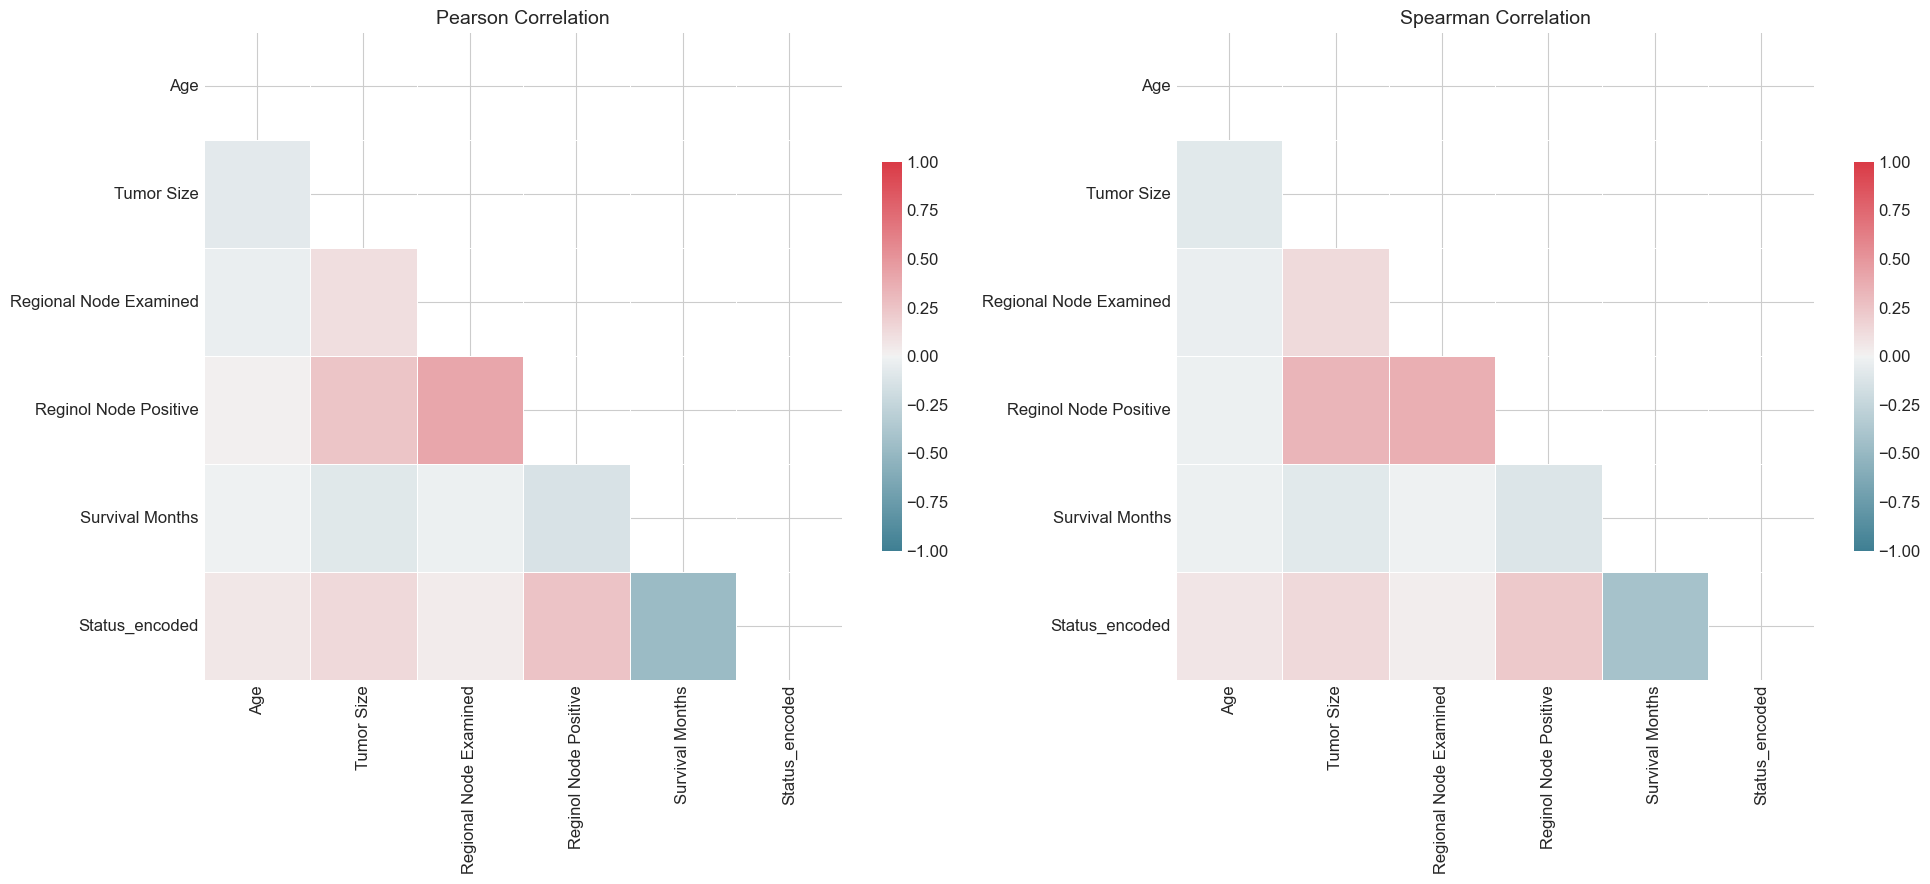


✅ Heatmaps salvos em: reports/figures/correlation_pearson_spearman.png

🔝 Top features correlacionadas com o target (Pearson):
Reginol Node Positive     0.256591
Tumor Size                0.134147
Age                       0.056036
Regional Node Examined    0.034705
Survival Months          -0.476622
Name: Status_encoded, dtype: float64

🔝 Top features correlacionadas com o target (Spearman):
Reginol Node Positive     0.219000
Tumor Size                0.140496
Age                       0.062623
Regional Node Examined    0.028763
Survival Months          -0.415477
Name: Status_encoded, dtype: float64


In [47]:
print("\n" + "="*70)
print("ANÁLISE DE CORRELAÇÃO - PEARSON E SPEARMAN")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status_encoded' not in df.columns:
    raise ValueError("Target 'Status_encoded' não encontrado")

# =========================
# USAR DADOS ORIGINAIS (SEM SCALING)
# =========================
numeric_df = df.select_dtypes(include=[np.number]).copy()

# =========================
# CORRELAÇÕES
# =========================
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Pearson
sns.heatmap(
    pearson_corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .6},
    ax=axes[0],
    annot=False
)
axes[0].set_title('Pearson Correlation', fontsize=14)

# Spearman
sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .6},
    ax=axes[1],
    annot=False
)
axes[1].set_title('Spearman Correlation', fontsize=14)

plt.tight_layout()
plt.savefig('../../reports/figures/correlation_pearson_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Heatmaps salvos em: reports/figures/correlation_pearson_spearman.png")

# =========================
# CORRELAÇÃO COM TARGET
# =========================
target = 'Status_encoded'

target_corr_p = pearson_corr[target].drop(target).sort_values(ascending=False)
target_corr_s = spearman_corr[target].drop(target).sort_values(ascending=False)

print("\n🔝 Top features correlacionadas com o target (Pearson):")
print(target_corr_p.head(10))

print("\n🔝 Top features correlacionadas com o target (Spearman):")
print(target_corr_s.head(10))

In [48]:
print("\n" + "="*70)
print("LISTANDO PARES COM |r| > 0.9 E SUGESTÕES DE REMOÇÃO")
print("="*70)

# =========================
# VALIDAÇÃO
# =========================
if 'Status_encoded' not in df.columns:
    raise ValueError("Target 'Status_encoded' não encontrado")

# =========================
# USAR DADOS ORIGINAIS
# =========================
numeric_df = df.select_dtypes(include=[np.number]).copy()

# =========================
# MATRIZ DE CORRELAÇÃO
# =========================
thresh = 0.9
corr = numeric_df.corr().abs()

# Triângulo superior
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# =========================
# IDENTIFICAR PARES
# =========================
pairs = []
for col in upper.columns:
    high = upper.index[upper[col] > thresh].tolist()
    for h in high:
        pairs.append((h, col, float(upper.loc[h, col])))

# =========================
# RESULTADO
# =========================
if not pairs:
    print(f"Nenhum par com |r| > {thresh} encontrado.")
else:
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
    print(f"Total pares encontrados: {len(pairs_sorted)}\n")

    for a, b, val in pairs_sorted[:20]:  # limitar visualização
        print(f"  {a} <-> {b}: {val:.3f}")

    # =========================
    # SUGESTÃO DE REMOÇÃO (INTELIGENTE)
    # =========================
    target_col = 'Status_encoded'
    suggested_drops = set()

    for a, b, val in pairs_sorted:
        corr_a = abs(corr.loc[a, target_col])
        corr_b = abs(corr.loc[b, target_col])

        # mantém a feature mais relevante para o target
        if corr_a >= corr_b:
            suggested_drops.add(b)
        else:
            suggested_drops.add(a)

    print("\n🧠 Sugestão de colunas a remover (redundância):")
    for col in sorted(suggested_drops):
        print(f"  - {col}")

    # =========================
    # EXPLICAÇÃO
    # =========================
    print("\n📊 Detalhe: correlação com target")
    for col in sorted(suggested_drops):
        print(f"  - {col}: {corr.loc[col, target_col]:.3f}")

print("\n✅ Sugestões prontas. Revise antes de aplicar remoções.")


LISTANDO PARES COM |r| > 0.9 E SUGESTÕES DE REMOÇÃO
Nenhum par com |r| > 0.9 encontrado.

✅ Sugestões prontas. Revise antes de aplicar remoções.
